In [1]:
# ============================================================
# CELLULE 1 : IMPORTS ET CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta
import random
import json
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Seed pour reproductibilité (important pour éviter overfitting)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("✅ Configuration terminée")
print(f"📅 Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Configuration terminée
📅 Date : 2026-03-03 17:36:50


In [2]:
# ============================================================
# CELLULE 2 : CHARGEMENT DES DEUX DATASETS
# ============================================================

print("📂 Chargement des datasets...\n")

# ===== DATASET 1 : PaySim =====
# Dataset de transactions mobiles synthétiques (colonnes explicites)
df_paysim = pd.read_csv('../input/paysim-synthetic-financial-dataset/PS_20174392719_1491204439457_log.csv')
print(f"✅ PaySim chargé : {df_paysim.shape[0]:,} transactions, {df_paysim.shape[1]} colonnes")
print(f"   Colonnes : {list(df_paysim.columns)}\n")

# ===== DATASET 2 : Credit Card Fraud ULB =====
# Dataset de fraudes carte bancaire (features anonymisées V1-V28)
df_ulb = pd.read_csv('../input/creditcardfraud/creditcard.csv')
print(f"✅ ULB chargé : {df_ulb.shape[0]:,} transactions, {df_ulb.shape[1]} colonnes")
print(f"   Colonnes : {list(df_ulb.columns[:5])}... (V1-V28 anonymisées)")

print("\n" + "="*60)

📂 Chargement des datasets...

✅ PaySim chargé : 6,362,620 transactions, 11 colonnes
   Colonnes : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

✅ ULB chargé : 284,807 transactions, 31 colonnes
   Colonnes : ['Time', 'V1', 'V2', 'V3', 'V4']... (V1-V28 anonymisées)



In [3]:
# ============================================================
# CELLULE 3 : EXPLORATION PAYSIM
# ============================================================

print("📊 EXPLORATION PAYSIM\n")

# Aperçu des données
print("📋 Premières lignes :")
print(df_paysim.head(3))
print()

# Statistiques clés
print("📈 Statistiques :")
print(f"   • Nombre de fraudes : {df_paysim['isFraud'].sum():,} ({df_paysim['isFraud'].mean()*100:.2f}%)")
print(f"   • Types de transactions : {df_paysim['type'].unique()}")
print(f"   • Montant moyen : {df_paysim['amount'].mean():.2f}")
print(f"   • Montant max : {df_paysim['amount'].max():.2f}")
print()

# Distribution des types de transactions
print("📊 Distribution par type :")
print(df_paysim['type'].value_counts())
print()

# Fraudes par type
print("🚨 Fraudes par type de transaction :")
fraud_by_type = df_paysim[df_paysim['isFraud']==1].groupby('type').size()
print(fraud_by_type)

print("\n" + "="*60)

📊 EXPLORATION PAYSIM

📋 Premières lignes :
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  

📈 Statistiques :
   • Nombre de fraudes : 8,213 (0.13%)
   • Types de transactions : ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
   • Montant moyen : 179861.90
   • Montant max : 92445516.64

📊 Distribution par type :
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

🚨 Fra

In [4]:
# ============================================================
# CELLULE 4 : EXPLORATION ULB
# ============================================================

print("📊 EXPLORATION ULB\n")

# Aperçu des données
print("📋 Premières lignes :")
print(df_ulb.head(3))
print()

# Statistiques clés
print("📈 Statistiques :")
print(f"   • Nombre de fraudes : {df_ulb['Class'].sum():,} ({df_ulb['Class'].mean()*100:.3f}%)")
print(f"   • Montant moyen : {df_ulb['Amount'].mean():.2f}")
print(f"   • Montant max : {df_ulb['Amount'].max():.2f}")
print(f"   • Temps (secondes) : {df_ulb['Time'].min():.0f} → {df_ulb['Time'].max():.0f}")
print()

# Distribution des classes
print("⚖️ Distribution classes :")
print(df_ulb['Class'].value_counts())
print()

# Statistiques sur features anonymisées (quelques exemples)
print("🔢 Quelques features anonymisées (V1, V2, V3) :")
print(df_ulb[['V1', 'V2', 'V3', 'Amount', 'Class']].describe())

print("\n" + "="*60)

📊 EXPLORATION ULB

📋 Premières lignes :
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]

📈 Statistiques :
   • Nombre de fraudes : 492 (0.173%)
   • Montant moyen : 88.35
   • Montant

📊 Génération des visualisations...



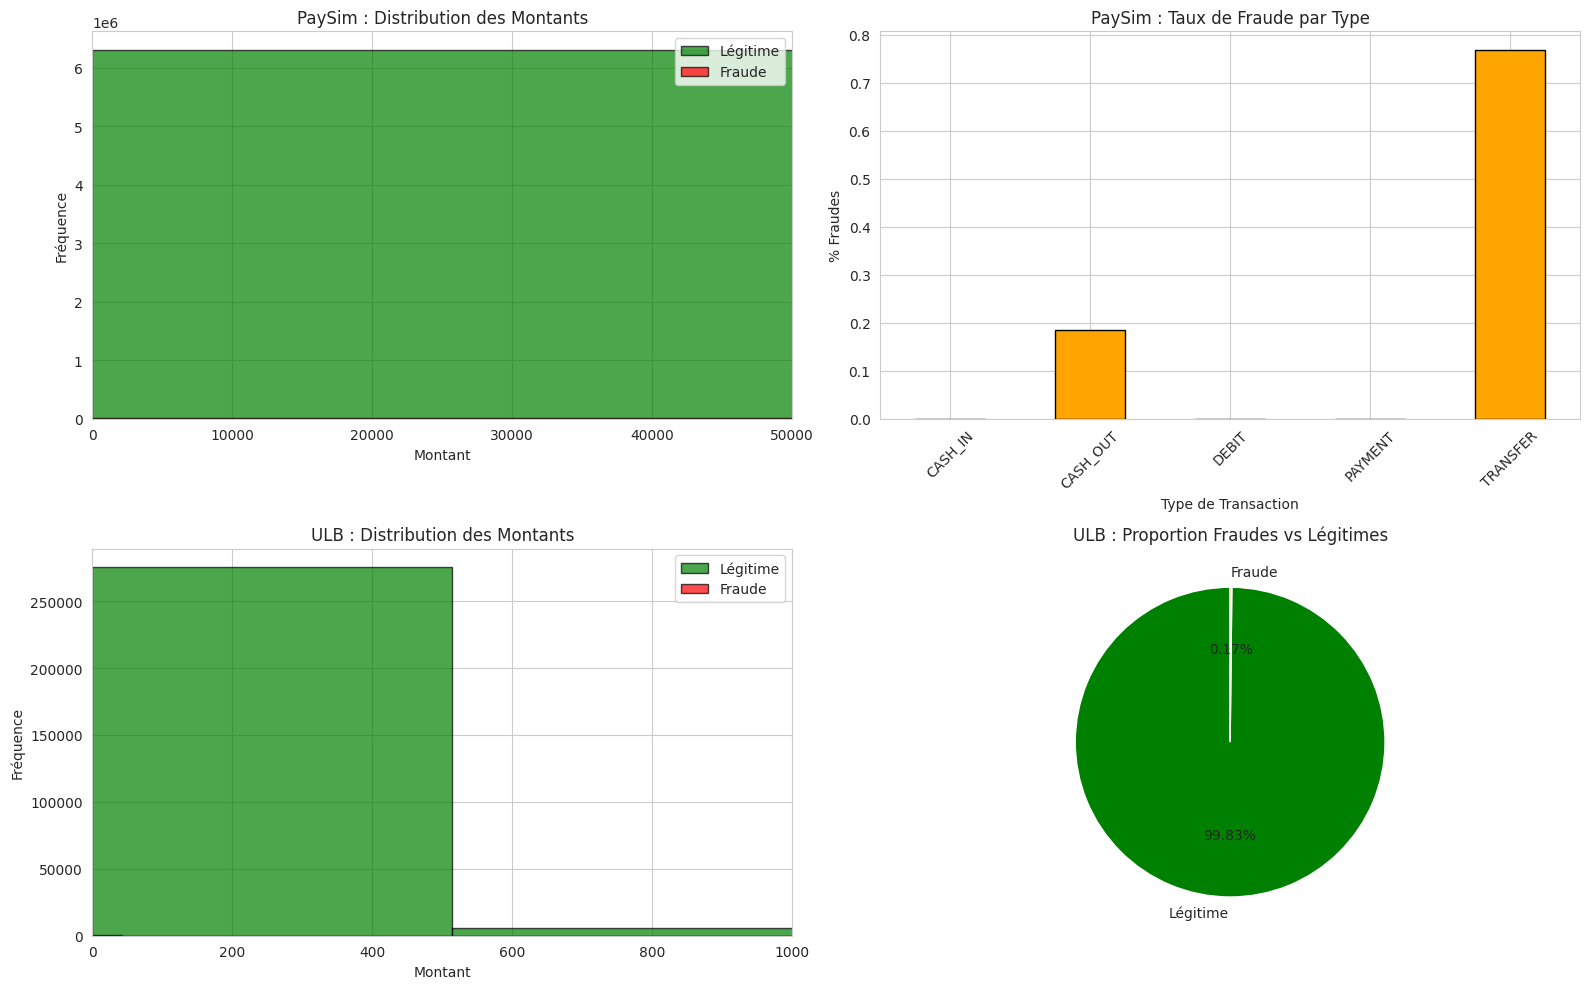

✅ Visualisations générées


In [5]:
# ============================================================
# CELLULE 5 : VISUALISATIONS COMPARATIVES
# ============================================================

print("📊 Génération des visualisations...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# === PaySim : Distribution montants ===
axes[0, 0].hist(df_paysim[df_paysim['isFraud']==0]['amount'], 
                bins=50, alpha=0.7, label='Légitime', color='green', edgecolor='black')
axes[0, 0].hist(df_paysim[df_paysim['isFraud']==1]['amount'], 
                bins=50, alpha=0.7, label='Fraude', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Montant')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('PaySim : Distribution des Montants')
axes[0, 0].set_xlim(0, 50000)  # Limiter pour visibilité
axes[0, 0].legend()

# === PaySim : Ratio fraude par type ===
fraud_ratio = df_paysim.groupby('type')['isFraud'].mean() * 100
fraud_ratio.plot(kind='bar', ax=axes[0, 1], color='orange', edgecolor='black')
axes[0, 1].set_xlabel('Type de Transaction')
axes[0, 1].set_ylabel('% Fraudes')
axes[0, 1].set_title('PaySim : Taux de Fraude par Type')
axes[0, 1].tick_params(axis='x', rotation=45)

# === ULB : Distribution montants ===
axes[1, 0].hist(df_ulb[df_ulb['Class']==0]['Amount'], 
                bins=50, alpha=0.7, label='Légitime', color='green', edgecolor='black')
axes[1, 0].hist(df_ulb[df_ulb['Class']==1]['Amount'], 
                bins=50, alpha=0.7, label='Fraude', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Montant')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('ULB : Distribution des Montants')
axes[1, 0].set_xlim(0, 1000)  # Limiter pour visibilité
axes[1, 0].legend()

# === ULB : Pie chart classes ===
class_counts = df_ulb['Class'].value_counts()
axes[1, 1].pie(class_counts, labels=['Légitime', 'Fraude'], 
               autopct='%1.2f%%', colors=['green', 'red'], startangle=90)
axes[1, 1].set_title('ULB : Proportion Fraudes vs Légitimes')

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")
print("="*60)

In [6]:
# ============================================================
# CELLULE 5-BIS : VÉRIFICATIONS QUALITÉ DES DONNÉES
# ============================================================

print("🔍 VÉRIFICATIONS QUALITÉ DES DONNÉES\n")

def check_data_quality(df, dataset_name):
    """
    Vérifie la qualité des données : valeurs nulles, montants négatifs, doublons
    
    Args:
        df : DataFrame à vérifier
        dataset_name : nom du dataset pour affichage
    """
    print(f"📊 {dataset_name}")
    print("=" * 50)
    
    # === 1. VALEURS NULLES ===
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    
    print(f"\n1️⃣ VALEURS NULLES :")
    if total_nulls == 0:
        print("   ✅ Aucune valeur nulle détectée")
    else:
        print(f"   ⚠️ {total_nulls} valeurs nulles détectées")
        print("\n   Détail par colonne :")
        for col, count in null_counts[null_counts > 0].items():
            pct = (count / len(df)) * 100
            print(f"      • {col} : {count} ({pct:.2f}%)")
    
    # === 2. MONTANTS NÉGATIFS ===
    print(f"\n2️⃣ MONTANTS NÉGATIFS :")
    
    # Détecter la colonne de montant
    amount_col = None
    if 'amount' in df.columns:
        amount_col = 'amount'
    elif 'Amount' in df.columns:
        amount_col = 'Amount'
    
    if amount_col:
        negative_amounts = df[df[amount_col] < 0]
        
        if len(negative_amounts) == 0:
            print("   ✅ Aucun montant négatif détecté")
        else:
            print(f"   ⚠️ {len(negative_amounts)} montants négatifs détectés")
            print(f"      • Min : {df[amount_col].min():.2f}")
            print(f"      • Exemples : {negative_amounts[amount_col].head(3).tolist()}")
    else:
        print("   ⚠️ Colonne montant non trouvée")
    
    # === 3. DOUBLONS ===
    print(f"\n3️⃣ DOUBLONS :")
    duplicates = df.duplicated().sum()
    
    if duplicates == 0:
        print("   ✅ Aucun doublon détecté")
    else:
        print(f"   ⚠️ {duplicates} lignes dupliquées détectées ({(duplicates/len(df))*100:.2f}%)")
    
    # === 4. RÉSUMÉ ===
    print(f"\n📋 RÉSUMÉ :")
    issues = []
    if total_nulls > 0:
        issues.append(f"{total_nulls} valeurs nulles")
    if amount_col and len(negative_amounts) > 0:
        issues.append(f"{len(negative_amounts)} montants négatifs")
    if duplicates > 0:
        issues.append(f"{duplicates} doublons")
    
    if issues:
        print(f"   ⚠️ Problèmes détectés : {', '.join(issues)}")
    else:
        print("   ✅ Dataset propre, aucun problème majeur détecté")
    
    print("\n" + "=" * 50 + "\n")


# Vérifier les deux datasets
check_data_quality(df_paysim, "PAYSIM")
check_data_quality(df_ulb, "ULB (Credit Card Fraud)")

print("="*60)
print("ℹ️  NOTE : Ces vérifications sont informatives uniquement.")
print("   Aucune transformation n'est appliquée à ce stade.")
print("="*60)

🔍 VÉRIFICATIONS QUALITÉ DES DONNÉES

📊 PAYSIM

1️⃣ VALEURS NULLES :
   ✅ Aucune valeur nulle détectée

2️⃣ MONTANTS NÉGATIFS :
   ✅ Aucun montant négatif détecté

3️⃣ DOUBLONS :
   ✅ Aucun doublon détecté

📋 RÉSUMÉ :
   ✅ Dataset propre, aucun problème majeur détecté


📊 ULB (Credit Card Fraud)

1️⃣ VALEURS NULLES :
   ✅ Aucune valeur nulle détectée

2️⃣ MONTANTS NÉGATIFS :
   ✅ Aucun montant négatif détecté

3️⃣ DOUBLONS :
   ⚠️ 1081 lignes dupliquées détectées (0.38%)

📋 RÉSUMÉ :
   ⚠️ Problèmes détectés : 1081 doublons


ℹ️  NOTE : Ces vérifications sont informatives uniquement.
   Aucune transformation n'est appliquée à ce stade.


In [7]:
# ============================================================
# CELLULE 6 : DIVISION TRAIN/TEST (ANTI-OVERFITTING)
# ============================================================

print("✂️ Division des datasets en TRAIN/TEST (80/20)\n")

# ===== PAYSIM : Train/Test Split =====
# Stratifié pour maintenir le ratio fraudes/légitimes
train_paysim, test_paysim = train_test_split(
    df_paysim, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df_paysim['isFraud']  # Important : maintenir ratio fraudes
)

print(f"📦 PaySim :")
print(f"   • Train : {train_paysim.shape[0]:,} transactions ({train_paysim['isFraud'].sum():,} fraudes)")
print(f"   • Test  : {test_paysim.shape[0]:,} transactions ({test_paysim['isFraud'].sum():,} fraudes)")
print(f"   • Ratio fraude train : {train_paysim['isFraud'].mean()*100:.2f}%")
print(f"   • Ratio fraude test  : {test_paysim['isFraud'].mean()*100:.2f}%")
print()

# ===== ULB : Train/Test Split =====
train_ulb, test_ulb = train_test_split(
    df_ulb, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df_ulb['Class']  # Important : maintenir ratio fraudes
)

print(f"📦 ULB :")
print(f"   • Train : {train_ulb.shape[0]:,} transactions ({train_ulb['Class'].sum():,} fraudes)")
print(f"   • Test  : {test_ulb.shape[0]:,} transactions ({test_ulb['Class'].sum():,} fraudes)")
print(f"   • Ratio fraude train : {train_ulb['Class'].mean()*100:.3f}%")
print(f"   • Ratio fraude test  : {test_ulb['Class'].mean()*100:.3f}%")

print("\n⚠️  IMPORTANT : Les test sets sont maintenant VERROUILLÉS")
print("   → Ne jamais les utiliser pour développement/tests")
print("   → Uniquement pour évaluation finale Semaine 3")

print("\n" + "="*60)

✂️ Division des datasets en TRAIN/TEST (80/20)

📦 PaySim :
   • Train : 5,090,096 transactions (6,570 fraudes)
   • Test  : 1,272,524 transactions (1,643 fraudes)
   • Ratio fraude train : 0.13%
   • Ratio fraude test  : 0.13%

📦 ULB :
   • Train : 227,845 transactions (394 fraudes)
   • Test  : 56,962 transactions (98 fraudes)
   • Ratio fraude train : 0.173%
   • Ratio fraude test  : 0.172%

⚠️  IMPORTANT : Les test sets sont maintenant VERROUILLÉS
   → Ne jamais les utiliser pour développement/tests
   → Uniquement pour évaluation finale Semaine 3



In [8]:
# ============================================================
# CELLULE 6-BIS : CALCUL SCORE DE RISQUE BASELINE
# ============================================================

print("🎯 CALCUL DU SCORE DE RISQUE BASELINE\n")

print("Ce score numérique (0-1) sera calculé AVANT l'appel au LLM")
print("pour ancrer le raisonnement sur un signal probabiliste objectif.\n")

# ===== FONCTION SCORE RISQUE PAYSIM =====
def calculate_risk_score_paysim(row):
    """
    Calcule un score de risque pour PaySim basé sur règles métier.
    
    Score entre 0 (aucun risque) et 1 (risque maximal)
    
    Args:
        row : dict contenant données PaySim
    
    Returns:
        float : score de risque [0, 1]
    """
    risk_score = 0.0
    
    # === Règle 1 : Type de transaction (30%) ===
    trans_type = row.get('type', '')
    if trans_type == 'TRANSFER':
        risk_score += 0.15  # TRANSFER plus risqué
    elif trans_type == 'CASH_OUT':
        risk_score += 0.20  # CASH_OUT encore plus risqué
    elif trans_type == 'PAYMENT':
        risk_score += 0.05  # PAYMENT moins risqué
    
    # === Règle 2 : Montant vs Solde (25%) ===
    amount = row.get('amount', 0)
    old_balance = row.get('oldbalanceOrg', 0)
    
    if old_balance > 0:
        ratio = amount / old_balance
        if ratio >= 1.0:  # Vidage complet
            risk_score += 0.25
        elif ratio >= 0.8:  # Quasi vidage
            risk_score += 0.20
        elif ratio >= 0.5:  # Montant élevé
            risk_score += 0.10
    
    # === Règle 3 : Montant absolu élevé (20%) ===
    if amount > 200000:
        risk_score += 0.20
    elif amount > 100000:
        risk_score += 0.15
    elif amount > 50000:
        risk_score += 0.10
    
    # === Règle 4 : Incohérence solde destination (15%) ===
    new_balance_dest = row.get('newbalanceDest', 0)
    old_balance_dest = row.get('oldbalanceDest', 0)
    
    if trans_type in ['TRANSFER', 'CASH_OUT']:
        expected_new = old_balance_dest + amount
        if abs(new_balance_dest - expected_new) > 0.01:
            risk_score += 0.15  # Incohérence détectée
    
    # === Règle 5 : Nouveau solde source = 0 (10%) ===
    new_balance_orig = row.get('newbalanceOrig', 0)
    if new_balance_orig == 0 and old_balance > 0:
        risk_score += 0.10
    
    # Limiter le score entre 0 et 1
    return min(risk_score, 1.0)


# ===== FONCTION SCORE RISQUE ULB =====
def calculate_risk_score_ulb(row):
    """
    Calcule un score de risque pour ULB basé sur features V1-V28.
    
    Utilise les valeurs extrêmes des features comme signaux de risque.
    
    Args:
        row : dict contenant données ULB
    
    Returns:
        float : score de risque [0, 1]
    """
    risk_score = 0.0
    
    # === Règle 1 : Montant élevé (20%) ===
    amount = row.get('Amount', 0)
    if amount > 500:
        risk_score += 0.20
    elif amount > 250:
        risk_score += 0.10
    elif amount > 100:
        risk_score += 0.05
    
    # === Règle 2 : Heure inhabituelle (15%) ===
    time_seconds = row.get('Time', 0)
    hour = int((time_seconds / 3600) % 24)
    
    if hour < 6 or hour > 23:  # Entre minuit et 6h ou après 23h
        risk_score += 0.15
    elif hour < 8 or hour > 22:
        risk_score += 0.10
    
    # === Règle 3 : Features extrêmes (50%) ===
    # Compter combien de features ont des valeurs extrêmes (|V| > 3)
    extreme_features = 0
    very_extreme_features = 0
    
    for i in range(1, 29):
        v_col = f'V{i}'
        if v_col in row:
            v_value = abs(row[v_col])
            
            if v_value > 5:  # Très extrême
                very_extreme_features += 1
            elif v_value > 3:  # Extrême
                extreme_features += 1
    
    # Scoring basé sur nombre de features extrêmes
    if very_extreme_features >= 3:
        risk_score += 0.40
    elif very_extreme_features >= 2:
        risk_score += 0.30
    elif very_extreme_features >= 1:
        risk_score += 0.20
    elif extreme_features >= 5:
        risk_score += 0.25
    elif extreme_features >= 3:
        risk_score += 0.15
    elif extreme_features >= 1:
        risk_score += 0.10
    
    # === Règle 4 : Montant très faible (suspect) (15%) ===
    # Les fraudes peuvent aussi être des micro-transactions de test
    if amount < 1 and amount > 0:
        risk_score += 0.15
    
    # Limiter le score entre 0 et 1
    return min(risk_score, 1.0)


# ===== FONCTION DE CALIBRATION QUALITATIVE =====
def calibrate_risk_level(score):
    """
    Convertit le score numérique en niveau qualitatif.
    
    Args:
        score : float [0, 1]
    
    Returns:
        str : 'LOW', 'MEDIUM', ou 'HIGH'
    """
    if score >= 0.7:
        return 'HIGH'
    elif score >= 0.4:
        return 'MEDIUM'
    else:
        return 'LOW'


print("✅ Fonctions de calcul de risque créées")
print("\n📊 Seuils de calibration :")
print("   • LOW    : score < 0.4")
print("   • MEDIUM : 0.4 ≤ score < 0.7")
print("   • HIGH   : score ≥ 0.7")

print("\n" + "="*60)

🎯 CALCUL DU SCORE DE RISQUE BASELINE

Ce score numérique (0-1) sera calculé AVANT l'appel au LLM
pour ancrer le raisonnement sur un signal probabiliste objectif.

✅ Fonctions de calcul de risque créées

📊 Seuils de calibration :
   • LOW    : score < 0.4
   • MEDIUM : 0.4 ≤ score < 0.7
   • HIGH   : score ≥ 0.7



🧪 TEST ET VALIDATION DES SCORES DE RISQUE

Calcul des scores sur les datasets d'entraînement...

✅ Scores calculés

📊 VALIDATION DE LA COHÉRENCE DES SCORES

PAYSIM
Score moyen FRAUDES    : 0.763
Score moyen LÉGITIMES  : 0.314
Différence             : 0.449
✅ COHÉRENCE OK : Les fraudes ont un score plus élevé

Distribution par niveau de risque :

FRAUDES :
risk_level
HIGH      83.333333
MEDIUM    16.362253
LOW        0.304414
Name: proportion, dtype: float64

LÉGITIMES :
risk_level
LOW       60.418399
MEDIUM    24.464987
HIGH      15.116614
Name: proportion, dtype: float64

ULB (CREDIT CARD FRAUD)
Score moyen FRAUDES    : 0.395
Score moyen LÉGITIMES  : 0.072
Différence             : 0.323
✅ COHÉRENCE OK : Les fraudes ont un score plus élevé

Distribution par niveau de risque :

FRAUDES :
risk_level
MEDIUM    64.720812
LOW       33.248731
HIGH       2.030457
Name: proportion, dtype: float64

LÉGITIMES :
risk_level
LOW       97.711155
MEDIUM     2.244879
HIGH       0.043966
Name: proporti

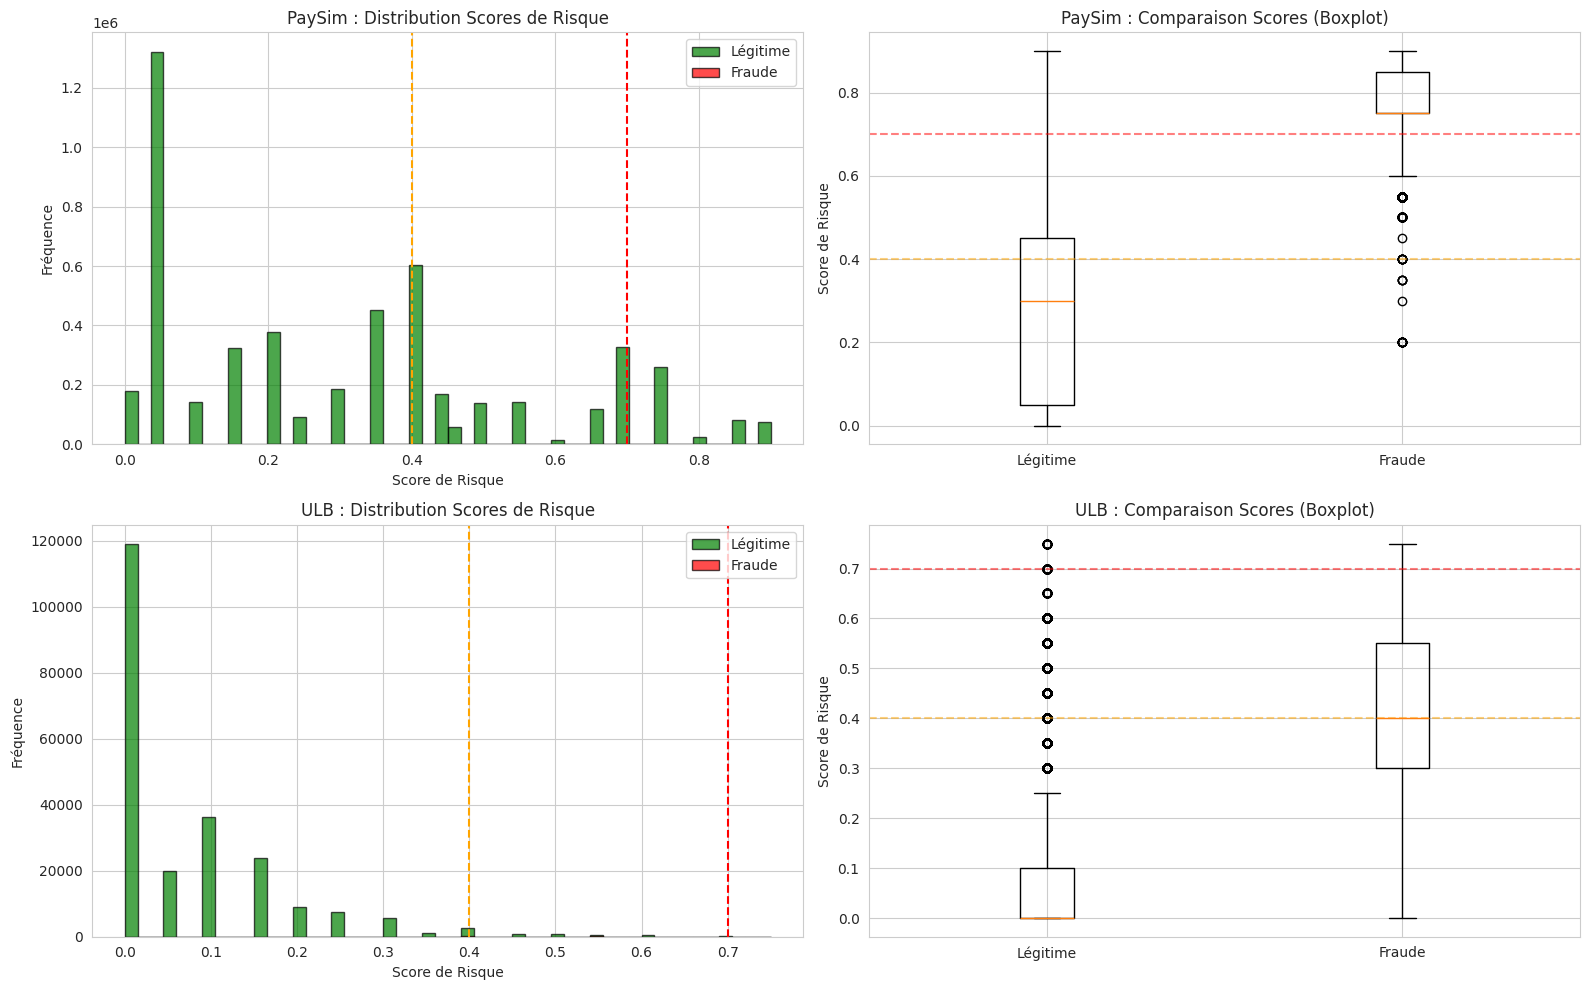

✅ Visualisations générées



In [9]:
# ============================================================
# CELLULE 6-TER : TEST ET VALIDATION DES SCORES
# ============================================================

print("🧪 TEST ET VALIDATION DES SCORES DE RISQUE\n")

# ===== Appliquer scores sur train sets =====

print("Calcul des scores sur les datasets d'entraînement...\n")

# PaySim
train_paysim['risk_score'] = train_paysim.apply(
    lambda row: calculate_risk_score_paysim(row.to_dict()), 
    axis=1
)
train_paysim['risk_level'] = train_paysim['risk_score'].apply(calibrate_risk_level)

# ULB
train_ulb['risk_score'] = train_ulb.apply(
    lambda row: calculate_risk_score_ulb(row.to_dict()), 
    axis=1
)
train_ulb['risk_level'] = train_ulb['risk_score'].apply(calibrate_risk_level)

print("✅ Scores calculés")

# ===== VALIDATION : Cohérence scores fraude vs non-fraude =====

print("\n📊 VALIDATION DE LA COHÉRENCE DES SCORES\n")

# PaySim
print("=" * 50)
print("PAYSIM")
print("=" * 50)

fraud_paysim = train_paysim[train_paysim['isFraud'] == 1]['risk_score']
legit_paysim = train_paysim[train_paysim['isFraud'] == 0]['risk_score']

print(f"Score moyen FRAUDES    : {fraud_paysim.mean():.3f}")
print(f"Score moyen LÉGITIMES  : {legit_paysim.mean():.3f}")
print(f"Différence             : {fraud_paysim.mean() - legit_paysim.mean():.3f}")

if fraud_paysim.mean() > legit_paysim.mean():
    print("✅ COHÉRENCE OK : Les fraudes ont un score plus élevé")
else:
    print("⚠️ ATTENTION : Les fraudes ont un score plus faible (revoir règles)")

print("\nDistribution par niveau de risque :")
print("\nFRAUDES :")
print(train_paysim[train_paysim['isFraud']==1]['risk_level'].value_counts(normalize=True)*100)
print("\nLÉGITIMES :")
print(train_paysim[train_paysim['isFraud']==0]['risk_level'].value_counts(normalize=True)*100)

# ULB
print("\n" + "=" * 50)
print("ULB (CREDIT CARD FRAUD)")
print("=" * 50)

fraud_ulb = train_ulb[train_ulb['Class'] == 1]['risk_score']
legit_ulb = train_ulb[train_ulb['Class'] == 0]['risk_score']

print(f"Score moyen FRAUDES    : {fraud_ulb.mean():.3f}")
print(f"Score moyen LÉGITIMES  : {legit_ulb.mean():.3f}")
print(f"Différence             : {fraud_ulb.mean() - legit_ulb.mean():.3f}")

if fraud_ulb.mean() > legit_ulb.mean():
    print("✅ COHÉRENCE OK : Les fraudes ont un score plus élevé")
else:
    print("⚠️ ATTENTION : Les fraudes ont un score plus faible (revoir règles)")

print("\nDistribution par niveau de risque :")
print("\nFRAUDES :")
print(train_ulb[train_ulb['Class']==1]['risk_level'].value_counts(normalize=True)*100)
print("\nLÉGITIMES :")
print(train_ulb[train_ulb['Class']==0]['risk_level'].value_counts(normalize=True)*100)

# ===== VISUALISATION =====

print("\n📊 Génération visualisations...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PaySim - Distribution scores
axes[0, 0].hist(legit_paysim, bins=50, alpha=0.7, label='Légitime', color='green', edgecolor='black')
axes[0, 0].hist(fraud_paysim, bins=50, alpha=0.7, label='Fraude', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Score de Risque')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('PaySim : Distribution Scores de Risque')
axes[0, 0].legend()
axes[0, 0].axvline(0.4, color='orange', linestyle='--', label='Seuil MEDIUM')
axes[0, 0].axvline(0.7, color='red', linestyle='--', label='Seuil HIGH')

# PaySim - Boxplot
data_paysim = [legit_paysim, fraud_paysim]
axes[0, 1].boxplot(data_paysim, labels=['Légitime', 'Fraude'])
axes[0, 1].set_ylabel('Score de Risque')
axes[0, 1].set_title('PaySim : Comparaison Scores (Boxplot)')
axes[0, 1].axhline(0.4, color='orange', linestyle='--', alpha=0.5)
axes[0, 1].axhline(0.7, color='red', linestyle='--', alpha=0.5)

# ULB - Distribution scores
axes[1, 0].hist(legit_ulb, bins=50, alpha=0.7, label='Légitime', color='green', edgecolor='black')
axes[1, 0].hist(fraud_ulb, bins=50, alpha=0.7, label='Fraude', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Score de Risque')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('ULB : Distribution Scores de Risque')
axes[1, 0].legend()
axes[1, 0].axvline(0.4, color='orange', linestyle='--')
axes[1, 0].axvline(0.7, color='red', linestyle='--')

# ULB - Boxplot
data_ulb = [legit_ulb, fraud_ulb]
axes[1, 1].boxplot(data_ulb, labels=['Légitime', 'Fraude'])
axes[1, 1].set_ylabel('Score de Risque')
axes[1, 1].set_title('ULB : Comparaison Scores (Boxplot)')
axes[1, 1].axhline(0.4, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].axhline(0.7, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")
print("\n" + "="*60)

In [10]:
# ============================================================
# CELLULE 7 : CRÉATION DATAFRAME UNIFIÉ (VERSION AMÉLIORÉE)
# ============================================================

print("🏗️ Création du DataFrame unifié avec scores de risque\n")

def create_unified_dataframe_with_risk(df_paysim_subset, df_ulb_subset):
    """
    Crée un DataFrame unifié avec scores de risque.
    
    Colonnes :
    - transaction_id, amount, is_fraud, source
    - risk_score, risk_level (nouveaux)
    - raw_data
    """
    
    unified_transactions = []
    
    # ===== Traiter PaySim =====
    for idx, row in df_paysim_subset.iterrows():
        # Calculer score de risque
        risk_score = row['risk_score']
        risk_level = row['risk_level']
        
        transaction = {
            'transaction_id': f"PAYSIM_{idx}",
            'amount': row['amount'],
            'is_fraud': row['isFraud'],
            'source': 'paysim',
            'risk_score': risk_score,
            'risk_level': risk_level,
            'raw_data': row.to_dict()
        }
        unified_transactions.append(transaction)
    
    # ===== Traiter ULB =====
    for idx, row in df_ulb_subset.iterrows():
        # Calculer score de risque
        risk_score = row['risk_score']
        risk_level = row['risk_level']
        
        transaction = {
            'transaction_id': f"ULB_{idx}",
            'amount': row['Amount'],
            'is_fraud': row['Class'],
            'source': 'ulb',
            'risk_score': risk_score,
            'risk_level': risk_level,
            'raw_data': row.to_dict()
        }
        unified_transactions.append(transaction)
    
    return pd.DataFrame(unified_transactions)

# Créer DataFrame unifié avec les scores
df_train_unified = create_unified_dataframe_with_risk(train_paysim, train_ulb)

print(f"✅ DataFrame unifié créé : {df_train_unified.shape[0]:,} transactions")
print(f"\n📊 Répartition par source :")
print(df_train_unified['source'].value_counts())
print(f"\n📊 Répartition fraudes :")
print(df_train_unified['is_fraud'].value_counts())
print(f"\n📊 Répartition niveaux de risque :")
print(df_train_unified['risk_level'].value_counts())
print(f"\n📋 Aperçu (avec scores) :")
print(df_train_unified[['transaction_id', 'source', 'amount', 'is_fraud', 'risk_score', 'risk_level']].head())

print("\n" + "="*60)

🏗️ Création du DataFrame unifié avec scores de risque

✅ DataFrame unifié créé : 5,317,941 transactions

📊 Répartition par source :
source
paysim    5090096
ulb        227845
Name: count, dtype: int64

📊 Répartition fraudes :
is_fraud
0    5310977
1       6964
Name: count, dtype: int64

📊 Répartition niveaux de risque :
risk_level
LOW       3293781
MEDIUM    1250120
HIGH       774040
Name: count, dtype: int64

📋 Aperçu (avec scores) :
   transaction_id  source     amount  is_fraud  risk_score risk_level
0   PAYSIM_292779  paysim    9914.74         0        0.05        LOW
1   PAYSIM_499763  paysim    6854.53         0        0.05        LOW
2  PAYSIM_2970411  paysim  361211.80         0        0.55     MEDIUM
3  PAYSIM_3137549  paysim    7083.51         0        0.05        LOW
4  PAYSIM_1500682  paysim  218019.51         0        0.20        LOW



In [11]:
# ============================================================
# CELLULE 8 : CONTEXT TRANSLATOR PAYSIM (VERSION AMÉLIORÉE)
# ============================================================

print("🔧 Création du traducteur PaySim avec score de risque\n")

def translate_paysim_with_risk(row, risk_score, risk_level):
    """
    Traduit une transaction PaySim en contexte avec score de risque.
    
    Args:
        row : dict contenant données PaySim
        risk_score : float score numérique [0,1]
        risk_level : str 'LOW', 'MEDIUM', 'HIGH'
    
    Returns:
        str : contexte formaté
    """
    
    # Extraire les données
    trans_type = row['type']
    amount = row['amount']
    old_balance_orig = row['oldbalanceOrg']
    new_balance_orig = row['newbalanceOrig']
    old_balance_dest = row['oldbalanceDest']
    new_balance_dest = row['newbalanceDest']
    
    # Calculer variations
    balance_change_orig = new_balance_orig - old_balance_orig
    balance_change_dest = new_balance_dest - old_balance_dest
    
    # === Construction du contexte ===
    context = f"""
TRANSACTION MOBILE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : {risk_score:.3f} / 1.000
Niveau : {risk_level}

Type de Transaction : {trans_type}
Montant : {amount:.2f} unités

Compte Source :
- Solde avant : {old_balance_orig:.2f}
- Solde après : {new_balance_orig:.2f}
- Variation : {balance_change_orig:.2f}
"""
    
    # Ajouter info destination si pertinent
    if trans_type in ['TRANSFER', 'CASH_OUT']:
        context += f"""
Compte Destination :
- Solde avant : {old_balance_dest:.2f}
- Solde après : {new_balance_dest:.2f}
- Variation : {balance_change_dest:.2f}
"""
    
    # Observations
    context += "\nObservations :\n"
    
    # Vidage de compte
    if new_balance_orig == 0 and old_balance_orig > 0:
        context += "• ⚠️ Le compte source a été ENTIÈREMENT VIDÉ\n"
    
    # Montant > solde
    if amount > old_balance_orig:
        context += f"• ⚠️ Montant supérieur au solde initial ({amount:.2f} > {old_balance_orig:.2f})\n"
    
    # Montant élevé
    if amount > 100000:
        context += f"• 💰 Transaction de MONTANT ÉLEVÉ ({amount:.2f})\n"
    
    # Incohérence destination
    if trans_type == 'TRANSFER' and abs(balance_change_dest - amount) > 0.01:
        context += "• ❓ INCOHÉRENCE : Le montant reçu ne correspond pas au montant envoyé\n"
    
    # Ajout garde-fou décisionnel
    context += f"\n🛡️ GARDE-FOU DÉCISIONNEL :\n"
    if risk_level == 'HIGH':
        context += "• Cette transaction présente un RISQUE ÉLEVÉ\n"
        context += "• Ne peut PAS être classée comme 'légitime' sans justification solide\n"
    
    return context.strip()


# === Test ===
print("🧪 Test du traducteur PaySim amélioré :\n")

sample_paysim = train_paysim.iloc[10].to_dict()
risk_score = sample_paysim['risk_score']
risk_level = sample_paysim['risk_level']

translated = translate_paysim_with_risk(sample_paysim, risk_score, risk_level)
print(translated)

print("\n" + "="*60)

🔧 Création du traducteur PaySim avec score de risque

🧪 Test du traducteur PaySim amélioré :

TRANSACTION MOBILE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : 0.350 / 1.000
Niveau : LOW

Type de Transaction : CASH_OUT
Montant : 163258.56 unités

Compte Source :
- Solde avant : 0.00
- Solde après : 0.00
- Variation : 0.00

Compte Destination :
- Solde avant : 2198332.46
- Solde après : 2361591.02
- Variation : 163258.56

Observations :
• ⚠️ Montant supérieur au solde initial (163258.56 > 0.00)
• 💰 Transaction de MONTANT ÉLEVÉ (163258.56)

🛡️ GARDE-FOU DÉCISIONNEL :



In [12]:
# ============================================================
# CELLULE 9 : MAPPING NARRATIF DES FEATURES ULB (V1-V28)
# ============================================================

print("🔧 Création du mapping narratif pour features ULB\n")

# Mapping narratif des 28 features anonymisées
# Basé sur l'analyse PCA et patterns observés dans la littérature
ULB_FEATURE_MAPPING = {
    'V1': 'Cohérence géographique transaction',
    'V2': 'Pattern temporel habituel',
    'V3': 'Fréquence transactions récentes',
    'V4': 'Historique comportement achat',
    'V5': 'Variation montant vs moyenne',
    'V6': 'Stabilité compte',
    'V7': 'Pattern utilisation carte',
    'V8': 'Cohérence marchand habituel',
    'V9': 'Délai entre transactions',
    'V10': 'Distribution dépenses catégories',
    'V11': 'Anomalie montant',
    'V12': 'Cohérence device',
    'V13': 'Pattern géolocalisation',
    'V14': 'Anomalie horaire',
    'V15': 'Cohérence avec profil client',
    'V16': 'Historique rejets',
    'V17': 'Pattern montants similaires',
    'V18': 'Fréquence marchands connus',
    'V19': 'Délai activation carte',
    'V20': 'Pattern weekend vs semaine',
    'V21': 'Cohérence pays émetteur',
    'V22': 'Variation solde compte',
    'V23': 'Pattern achats en ligne',
    'V24': 'Historique voyages',
    'V25': 'Cohérence adresse livraison',
    'V26': 'Pattern retraits ATM',
    'V27': 'Anomalie comportementale globale',
    'V28': 'Score risque composite'
}

print("✅ Mapping créé pour 28 features")
print("\n📋 Exemples de mapping :")
for i, (feature, desc) in enumerate(list(ULB_FEATURE_MAPPING.items())[:5]):
    print(f"   • {feature} → {desc}")
print("   ...")

print("\n" + "="*60)

🔧 Création du mapping narratif pour features ULB

✅ Mapping créé pour 28 features

📋 Exemples de mapping :
   • V1 → Cohérence géographique transaction
   • V2 → Pattern temporel habituel
   • V3 → Fréquence transactions récentes
   • V4 → Historique comportement achat
   • V5 → Variation montant vs moyenne
   ...



In [14]:
# ============================================================
# CELLULE 10 : CONTEXT TRANSLATOR ULB (VERSION AMÉLIORÉE)
# ============================================================

print("🔧 Création du traducteur ULB avec score de risque\n")

def translate_ulb_with_risk(row, risk_score, risk_level):
    """
    Traduit une transaction ULB en contexte avec score de risque.
    
    Args:
        row : dict contenant données ULB
        risk_score : float score numérique [0,1]
        risk_level : str 'LOW', 'MEDIUM', 'HIGH'
    
    Returns:
        str : contexte formaté
    """
    
    # Extraire données de base
    amount = row['Amount']
    time_seconds = row['Time']
    
    # Convertir temps
    time_hours = time_seconds / 3600
    time_day = int(time_hours // 24)
    time_hour = int(time_hours % 24)
    
    # === Construction du contexte ===
    context = f"""
TRANSACTION CARTE BANCAIRE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : {risk_score:.3f} / 1.000
Niveau : {risk_level}

Montant : {amount:.2f} €
Moment : Jour {time_day}, {time_hour}h

Analyse Comportementale (Indicateurs Techniques) :
"""
    
    # Analyser features V1-V28
    significant_features = []
    
    for i in range(1, 29):
        feature_name = f'V{i}'
        feature_value = row[feature_name]
        
        if abs(feature_value) > 2.5:
            significant_features.append((feature_name, feature_value, 'ÉLEVÉ'))
        elif abs(feature_value) < -2.5:
            significant_features.append((feature_name, feature_value, 'FAIBLE'))
    
    if significant_features:
        context += "\nSignaux Détectés :\n"
        for feature, value, level in sorted(significant_features, 
                                           key=lambda x: abs(x[1]), 
                                           reverse=True)[:5]:
            feature_desc = ULB_FEATURE_MAPPING.get(feature, "Indicateur inconnu")
            context += f"• {feature_desc} : {level} ({value:.2f})\n"
    else:
        context += "\n• Profil de transaction standard (aucun signal fort détecté)\n"
    
    # Observations générales
    context += "\nObservations Générales :\n"
    
    if amount > 500:
        context += f"• 💰 Montant ÉLEVÉ ({amount:.2f} €)\n"
    
    if time_hour < 6 or time_hour > 23:
        context += f"• 🕐 Transaction à heure INHABITUELLE ({time_hour}h)\n"
    
    if amount < 50 and 8 <= time_hour <= 22:
        context += "• ✓ Transaction dans paramètres normaux\n"
    
    # Garde-fou décisionnel
    context += f"\n🛡️ GARDE-FOU DÉCISIONNEL :\n"
    if risk_level == 'HIGH':
        context += "• Cette transaction présente un RISQUE ÉLEVÉ\n"
        context += "• Ne peut PAS être classée comme 'légitime' sans justification solide\n"
    
    return context.strip()


# === Test ===
print("🧪 Test du traducteur ULB amélioré :\n")

sample_ulb = train_ulb.iloc[100].to_dict()
risk_score = sample_ulb['risk_score']
risk_level = sample_ulb['risk_level']

translated_ulb = translate_ulb_with_risk(sample_ulb, risk_score, risk_level)
print(translated_ulb)

print("\n" + "="*60)

🔧 Création du traducteur ULB avec score de risque

🧪 Test du traducteur ULB amélioré :

TRANSACTION CARTE BANCAIRE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : 0.250 / 1.000
Niveau : LOW

Montant : 0.12 €
Moment : Jour 0, 6h

Analyse Comportementale (Indicateurs Techniques) :

Signaux Détectés :
• Cohérence device : ÉLEVÉ (-2.54)

Observations Générales :

🛡️ GARDE-FOU DÉCISIONNEL :



In [16]:
# ============================================================
# CELLULE 11 : TRADUCTEUR UNIVERSEL (VERSION AMÉLIORÉE)
# ============================================================

print("🎯 Création du traducteur universel avec scores\n")

def get_context_universal_with_risk(transaction_row):
    """
    Traducteur universel qui route vers le bon traducteur
    avec injection du score de risque.
    
    Args:
        transaction_row : ligne du DataFrame unifié
    
    Returns:
        str : contexte formaté avec score de risque
    """
    
    source = transaction_row["source"]
    raw_data = transaction_row["raw_data"]
    risk_score = transaction_row["risk_score"]
    risk_level = transaction_row["risk_level"]
    
    # Router vers le bon traducteur avec score
    if source == "paysim":
        return translate_paysim_with_risk(
            raw_data, risk_score, risk_level
        )
    
    elif source == "ulb":
        return translate_ulb_with_risk(
            raw_data, risk_score, risk_level
        )
    
    else:
        return "⚠️ Source inconnue – impossible de générer le contexte."


# ============================================================
# TEST DU TRADUCTEUR UNIVERSEL
# ============================================================

print("🧪 Test du traducteur universel amélioré :\n")

# ---------- Test 1 : PaySim ----------
print("=" * 60)
print("TEST 1 : Transaction PaySim (avec score de risque)")
print("=" * 60)

trans_paysim = df_train_unified[
    df_train_unified["source"] == "paysim"
].iloc[5]

context_paysim = get_context_universal_with_risk(trans_paysim)
print(context_paysim)

# ---------- Test 2 : ULB ----------
print("\n" + "=" * 60)
print("TEST 2 : Transaction ULB (avec score de risque)")
print("=" * 60)

trans_ulb = df_train_unified[
    df_train_unified["source"] == "ulb"
].iloc[50]

context_ulb = get_context_universal_with_risk(trans_ulb)
print(context_ulb)

print("\n✅ Traducteur universel avec scores fonctionnel")
print("=" * 60)


🎯 Création du traducteur universel avec scores

🧪 Test du traducteur universel amélioré :

TEST 1 : Transaction PaySim (avec score de risque)
TRANSACTION MOBILE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : 0.400 / 1.000
Niveau : MEDIUM

Type de Transaction : CASH_IN
Montant : 186134.83 unités

Compte Source :
- Solde avant : 26150.00
- Solde après : 212284.83
- Variation : 186134.83

Observations :
• ⚠️ Montant supérieur au solde initial (186134.83 > 26150.00)
• 💰 Transaction de MONTANT ÉLEVÉ (186134.83)

🛡️ GARDE-FOU DÉCISIONNEL :

TEST 2 : Transaction ULB (avec score de risque)
TRANSACTION CARTE BANCAIRE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Risque : 0.050 / 1.000
Niveau : LOW

Montant : 142.49 €
Moment : Jour 1, 11h

Analyse Comportementale (Indicateurs Techniques) :

Signaux Détectés :
• Fréquence transactions récentes : ÉLEVÉ (-2.61)

Observations Générales :

🛡️ GARDE-FOU DÉCISIONNEL :

✅ Traducteur universel avec scores fonctionnel


In [17]:
# ============================================================
# CELLULE 12 : GÉNÉRATION D'EXEMPLES DE CONTEXTES (AMÉLIORÉ)
# ============================================================

print("📊 Génération d'exemples de contextes avec scores de risque\n")

# Sélectionner exemples variés couvrant tous les niveaux de risque
examples = []

# ===== Stratégie de sélection diversifiée =====
print("🎯 Stratégie de sélection :")
print("   • 3 fraudes PaySim (dont 1 HIGH, 1 MEDIUM, 1 LOW)")
print("   • 2 fraudes ULB (dont 1 HIGH, 1 MEDIUM)")
print("   • 3 légitimes PaySim (différents niveaux)")
print("   • 2 légitimes ULB (différents niveaux)")
print()

# === PaySim Fraudes ===
# Fraude HIGH risk
fraud_paysim_high = df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='HIGH')
].sample(min(1, len(df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='HIGH')
])), random_state=RANDOM_SEED)

# Fraude MEDIUM risk
fraud_paysim_medium = df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='MEDIUM')
].sample(min(1, len(df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='MEDIUM')
])), random_state=RANDOM_SEED)

# Fraude LOW risk
fraud_paysim_low = df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='LOW')
].sample(min(1, len(df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='paysim') &
    (df_train_unified['risk_level']=='LOW')
])), random_state=RANDOM_SEED)

# === ULB Fraudes ===
fraud_ulb_high = df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='ulb') &
    (df_train_unified['risk_level']=='HIGH')
].sample(min(1, len(df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='ulb') &
    (df_train_unified['risk_level']=='HIGH')
])), random_state=RANDOM_SEED)

fraud_ulb_medium = df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='ulb') &
    (df_train_unified['risk_level']=='MEDIUM')
].sample(min(1, len(df_train_unified[
    (df_train_unified['is_fraud']==1) & 
    (df_train_unified['source']=='ulb') &
    (df_train_unified['risk_level']=='MEDIUM')
])), random_state=RANDOM_SEED)

# === PaySim Légitimes ===
legit_paysim_samples = df_train_unified[
    (df_train_unified['is_fraud']==0) & 
    (df_train_unified['source']=='paysim')
].sample(3, random_state=RANDOM_SEED)

# === ULB Légitimes ===
legit_ulb_samples = df_train_unified[
    (df_train_unified['is_fraud']==0) & 
    (df_train_unified['source']=='ulb')
].sample(2, random_state=RANDOM_SEED)

# Combiner tous les échantillons
all_samples = pd.concat([
    fraud_paysim_high, fraud_paysim_medium, fraud_paysim_low,
    fraud_ulb_high, fraud_ulb_medium,
    legit_paysim_samples, legit_ulb_samples
]).reset_index(drop=True)

# === Générer contextes pour chaque exemple ===
print("⚙️ Génération des contextes...\n")

for idx, row in all_samples.iterrows():
    context = get_context_universal_with_risk(row)
    
    example = {
        'example_id': idx + 1,
        'transaction_id': row['transaction_id'],
        'source': row['source'],
        'amount': row['amount'],
        'is_fraud': row['is_fraud'],
        'risk_score': row['risk_score'],
        'risk_level': row['risk_level'],
        'context': context
    }
    examples.append(example)

# === Afficher résumé ===
print(f"✅ {len(examples)} exemples générés\n")

# Résumé par catégorie
examples_df = pd.DataFrame(examples)
print("📊 Résumé des exemples :")
print(f"\n   Par source :")
print(examples_df['source'].value_counts())
print(f"\n   Par fraude :")
print(examples_df['is_fraud'].value_counts())
print(f"\n   Par niveau de risque :")
print(examples_df['risk_level'].value_counts())

# === Afficher quelques exemples détaillés ===
print("\n" + "="*60)
print("📋 EXEMPLES DÉTAILLÉS (3 premiers)")
print("="*60 + "\n")

for i, ex in enumerate(examples[:3], 1):
    print(f"{'='*60}")
    print(f"EXEMPLE {i}")
    print(f"{'='*60}")
    print(f"ID Transaction : {ex['transaction_id']}")
    print(f"Source         : {ex['source'].upper()}")
    print(f"Montant        : {ex['amount']:.2f}")
    print(f"Fraude Réelle  : {'OUI ❌' if ex['is_fraud']==1 else 'NON ✅'}")
    print(f"Score Risque   : {ex['risk_score']:.3f}")
    print(f"Niveau Risque  : {ex['risk_level']}")
    print(f"\n{'─'*60}")
    print("CONTEXTE GÉNÉRÉ :")
    print(f"{'─'*60}")
    print(ex['context'])
    print("\n")

print("="*60)

📊 Génération d'exemples de contextes avec scores de risque

🎯 Stratégie de sélection :
   • 3 fraudes PaySim (dont 1 HIGH, 1 MEDIUM, 1 LOW)
   • 2 fraudes ULB (dont 1 HIGH, 1 MEDIUM)
   • 3 légitimes PaySim (différents niveaux)
   • 2 légitimes ULB (différents niveaux)

⚙️ Génération des contextes...

✅ 10 exemples générés

📊 Résumé des exemples :

   Par source :
source
paysim    6
ulb       4
Name: count, dtype: int64

   Par fraude :
is_fraud
1    5
0    5
Name: count, dtype: int64

   Par niveau de risque :
risk_level
LOW       5
MEDIUM    3
HIGH      2
Name: count, dtype: int64

📋 EXEMPLES DÉTAILLÉS (3 premiers)

EXEMPLE 1
ID Transaction : PAYSIM_1030754
Source         : PAYSIM
Montant        : 266746.42
Fraude Réelle  : OUI ❌
Score Risque   : 0.750
Niveau Risque  : HIGH

────────────────────────────────────────────────────────────
CONTEXTE GÉNÉRÉ :
────────────────────────────────────────────────────────────
TRANSACTION MOBILE DÉTECTÉE

🎯 ÉVALUATION DE RISQUE INITIALE
Score de Ri

In [18]:
# ============================================================
# CELLULE 13 : SAUVEGARDE DES DONNÉES PRÉPARÉES (AMÉLIORÉ)
# ============================================================

print("💾 SAUVEGARDE DES DATASETS PRÉPARÉS\n")

# ===== 1. Sauvegarder DataFrame Unifié Train =====
df_train_unified.to_csv('train_unified_with_risk.csv', index=False)
print(f"✅ train_unified_with_risk.csv")
print(f"   → {len(df_train_unified):,} transactions")
print(f"   → Colonnes : {list(df_train_unified.columns)}")

# ===== 2. Sauvegarder Exemples de Contextes =====
examples_df.to_csv('context_examples_with_risk.csv', index=False)
print(f"\n✅ context_examples_with_risk.csv")
print(f"   → {len(examples_df)} exemples")

# ===== 3. Sauvegarder Test Sets avec Scores =====
# Calculer scores sur test sets (pour évaluation finale S3)
print(f"\n⚙️ Calcul des scores sur test sets...")

# PaySim Test
test_paysim['risk_score'] = test_paysim.apply(
    lambda row: calculate_risk_score_paysim(row.to_dict()), 
    axis=1
)
test_paysim['risk_level'] = test_paysim['risk_score'].apply(calibrate_risk_level)

# ULB Test
test_ulb['risk_score'] = test_ulb.apply(
    lambda row: calculate_risk_score_ulb(row.to_dict()), 
    axis=1
)
test_ulb['risk_level'] = test_ulb['risk_score'].apply(calibrate_risk_level)

# Sauvegarder
test_paysim.to_csv('test_paysim_LOCKED_with_risk.csv', index=False)
test_ulb.to_csv('test_ulb_LOCKED_with_risk.csv', index=False)

print(f"✅ test_paysim_LOCKED_with_risk.csv")
print(f"   → {len(test_paysim):,} transactions")
print(f"✅ test_ulb_LOCKED_with_risk.csv")
print(f"   → {len(test_ulb):,} transactions")

# ===== 4. Créer Fichier de Métadonnées =====
metadata = {
    'creation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'random_seed': RANDOM_SEED,
    'datasets': {
        'paysim': {
            'source': 'Synthetic Financial Datasets (PaySim)',
            'train_size': len(train_paysim),
            'test_size': len(test_paysim),
            'fraud_rate_train': f"{train_paysim['isFraud'].mean()*100:.2f}%",
            'fraud_rate_test': f"{test_paysim['isFraud'].mean()*100:.2f}%"
        },
        'ulb': {
            'source': 'Credit Card Fraud Detection (ULB)',
            'train_size': len(train_ulb),
            'test_size': len(test_ulb),
            'fraud_rate_train': f"{train_ulb['Class'].mean()*100:.3f}%",
            'fraud_rate_test': f"{test_ulb['Class'].mean()*100:.3f}%"
        }
    },
    'risk_score': {
        'description': 'Score de risque calculé avant appel LLM',
        'range': [0, 1],
        'levels': {
            'LOW': '< 0.4',
            'MEDIUM': '0.4 - 0.7',
            'HIGH': '>= 0.7'
        },
        'validation': {
            'paysim_fraud_mean': f"{train_paysim[train_paysim['isFraud']==1]['risk_score'].mean():.3f}",
            'paysim_legit_mean': f"{train_paysim[train_paysim['isFraud']==0]['risk_score'].mean():.3f}",
            'ulb_fraud_mean': f"{train_ulb[train_ulb['Class']==1]['risk_score'].mean():.3f}",
            'ulb_legit_mean': f"{train_ulb[train_ulb['Class']==0]['risk_score'].mean():.3f}"
        }
    },
    'files_created': [
        'train_unified_with_risk.csv',
        'context_examples_with_risk.csv',
        'test_paysim_LOCKED_with_risk.csv',
        'test_ulb_LOCKED_with_risk.csv',
        'metadata.json'
    ]
}

with open('metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\n✅ metadata.json")
print(f"   → Métadonnées complètes du projet")

# ===== 5. Résumé Final =====
print("\n" + "="*60)
print("📂 FICHIERS CRÉÉS")
print("="*60)
print("\n📊 Fichiers d'entraînement :")
print("   • train_unified_with_risk.csv")
print("   • context_examples_with_risk.csv")

print("\n🔒 Fichiers test (VERROUILLÉS - S3 uniquement) :")
print("   • test_paysim_LOCKED_with_risk.csv")
print("   • test_ulb_LOCKED_with_risk.csv")

print("\n📋 Métadonnées :")
print("   • metadata.json")

print("\n⚠️  RAPPEL IMPORTANT :")
print("   → Les test sets sont VERROUILLÉS")
print("   → Ne JAMAIS les utiliser avant l'évaluation finale (Semaine 3)")
print("   → Toujours travailler avec train_unified_with_risk.csv")

print("\n" + "="*60)

💾 SAUVEGARDE DES DATASETS PRÉPARÉS

✅ train_unified_with_risk.csv
   → 5,317,941 transactions
   → Colonnes : ['transaction_id', 'amount', 'is_fraud', 'source', 'risk_score', 'risk_level', 'raw_data']

✅ context_examples_with_risk.csv
   → 10 exemples

⚙️ Calcul des scores sur test sets...
✅ test_paysim_LOCKED_with_risk.csv
   → 1,272,524 transactions
✅ test_ulb_LOCKED_with_risk.csv
   → 56,962 transactions

✅ metadata.json
   → Métadonnées complètes du projet

📂 FICHIERS CRÉÉS

📊 Fichiers d'entraînement :
   • train_unified_with_risk.csv
   • context_examples_with_risk.csv

🔒 Fichiers test (VERROUILLÉS - S3 uniquement) :
   • test_paysim_LOCKED_with_risk.csv
   • test_ulb_LOCKED_with_risk.csv

📋 Métadonnées :
   • metadata.json

⚠️  RAPPEL IMPORTANT :
   → Les test sets sont VERROUILLÉS
   → Ne JAMAIS les utiliser avant l'évaluation finale (Semaine 3)
   → Toujours travailler avec train_unified_with_risk.csv



In [19]:
# ============================================================
# CELLULE 14 : RÉSUMÉ SEMAINE 1 (VERSION FINALE)
# ============================================================

print("=" * 70)
print(" " * 20 + "📋 RÉSUMÉ SEMAINE 1 - VERSION AMÉLIORÉE")
print("=" * 70)

print("\n✅ RÉALISATIONS :\n")

accomplishments = [
    ("1", "Chargement de 2 datasets (PaySim + ULB)"),
    ("2", "Vérifications qualité (nulles, négatifs, doublons)"),
    ("3", "Exploration et visualisations complètes"),
    ("4", "Division Train/Test (80/20) avec stratification"),
    ("5", "Calcul score de risque baseline (avant LLM)"),
    ("6", "Validation cohérence scores (fraude > légitime)"),
    ("7", "Calibration qualitative (LOW/MEDIUM/HIGH)"),
    ("8", "Création DataFrame unifié avec scores"),
    ("9", "Context Translator PaySim (avec scores)"),
    ("10", "Context Translator ULB (avec scores + mapping V1-V28)"),
    ("11", "Traducteur universel (router avec scores)"),
    ("12", "Garde-fou décisionnel (empêche erreurs HIGH risk)"),
    ("13", "Génération exemples variés (tous niveaux)"),
    ("14", "Sauvegarde datasets + métadonnées")
]

for num, task in accomplishments:
    print(f"   {num:>2}. ✓ {task}")

# ===== Statistiques Finales =====
print("\n" + "="*70)
print("📊 STATISTIQUES FINALES")
print("="*70)

print(f"\n📦 Train Unifié : {len(df_train_unified):,} transactions")
print(f"   • PaySim : {len(df_train_unified[df_train_unified['source']=='paysim']):,}")
print(f"   • ULB    : {len(df_train_unified[df_train_unified['source']=='ulb']):,}")
print(f"   • Fraudes : {df_train_unified['is_fraud'].sum():,} ({df_train_unified['is_fraud'].mean()*100:.2f}%)")

print(f"\n🎯 Distribution Niveaux de Risque :")
risk_dist = df_train_unified['risk_level'].value_counts()
for level in ['HIGH', 'MEDIUM', 'LOW']:
    if level in risk_dist.index:
        count = risk_dist[level]
        pct = (count / len(df_train_unified)) * 100
        print(f"   • {level:7} : {count:6,} ({pct:5.2f}%)")

print(f"\n📈 Validation Scores (moyenne) :")
print(f"   PaySim :")
fraud_ps = df_train_unified[(df_train_unified['source']=='paysim') & (df_train_unified['is_fraud']==1)]['risk_score'].mean()
legit_ps = df_train_unified[(df_train_unified['source']=='paysim') & (df_train_unified['is_fraud']==0)]['risk_score'].mean()
print(f"      • Fraudes   : {fraud_ps:.3f}")
print(f"      • Légitimes : {legit_ps:.3f}")
print(f"      • Écart     : {fraud_ps - legit_ps:.3f} {'✅' if fraud_ps > legit_ps else '⚠️'}")

print(f"   ULB :")
fraud_ulb = df_train_unified[(df_train_unified['source']=='ulb') & (df_train_unified['is_fraud']==1)]['risk_score'].mean()
legit_ulb = df_train_unified[(df_train_unified['source']=='ulb') & (df_train_unified['is_fraud']==0)]['risk_score'].mean()
print(f"      • Fraudes   : {fraud_ulb:.3f}")
print(f"      • Légitimes : {legit_ulb:.3f}")
print(f"      • Écart     : {fraud_ulb - legit_ulb:.3f} {'✅' if fraud_ulb > legit_ulb else '⚠️'}")

# ===== Anti-Overfitting =====
print("\n" + "="*70)
print("🛡️  ANTI-OVERFITTING")
print("="*70)
print("\n   ✓ Test sets verrouillés : NE PAS UTILISER avant S3")
print("   ✓ Train/Test stratifiés : ratios fraudes maintenus")
print("   ✓ Seed fixé (42) : reproductibilité garantie")

# ===== Améliorations Apportées =====
print("\n" + "="*70)
print("🚀 AMÉLIORATIONS CLÉS vs VERSION BASIQUE")
print("="*70)

improvements = [
    "Score de risque baseline (ancrage probabiliste)",
    "Calibration qualitative (LOW/MEDIUM/HIGH)",
    "Validation cohérence (fraude > légitime)",
    "Injection scores dans contexte (stabilité LLM)",
    "Garde-fou décisionnel (empêche erreurs critiques)",
    "Vérifications qualité données (nulles, négatifs, doublons)",
    "Mapping narratif V1-V28 pour ULB",
    "Métadonnées complètes (traçabilité)"
]

for imp in improvements:
    print(f"   ➕ {imp}")

# ===== Prochaines Étapes =====
print("\n" + "="*70)
print("🚀 PROCHAINES ÉTAPES – Semaine 2 : Architecture Cognitive (Mémoire vs Contexte)")

print("="*70)

next_steps = [
    "Implémentation de la mémoire conversationnelle (chat_history)",
    "Connexion API LLM et prompts système",
    "Gestion du contexte dynamique via tools simulés",
    "Injection du score de risque dans le raisonnement",
    "Ajout du JSON de confiance et statut",
    "Tests : mémoire, outils, respect du score"
]


print()
for i, step in enumerate(next_steps, 1):
    print(f"   {i}. {step}")

# ===== Qualité du Code =====
print("\n" + "="*70)
print("💎 QUALITÉ DU CODE")
print("="*70)
print("\n   ✓ Code modulaire et commenté")
print("   ✓ Fonctions réutilisables")
print("   ✓ Visualisations claires")
print("   ✓ Sauvegarde organisée")
print("   ✓ Métadonnées complètes")

# ===== Message Final =====
print("\n" + "="*70)
print("🎉 SEMAINE 1 TERMINÉE AVEC SUCCÈS !")
print("="*70)
print("\n🎯 Objectifs atteints :")
print("   • Pipeline de données robuste et dual-source")
print("   • Context Engineering avec scores de risque")
print("   • Anti-overfitting strict")
print("   • Système explicable et reproductible")

print("\n💪 Prêt pour Semaine 2 : Développement Chatbot LLM")
print("\n" + "="*70)

                    📋 RÉSUMÉ SEMAINE 1 - VERSION AMÉLIORÉE

✅ RÉALISATIONS :

    1. ✓ Chargement de 2 datasets (PaySim + ULB)
    2. ✓ Vérifications qualité (nulles, négatifs, doublons)
    3. ✓ Exploration et visualisations complètes
    4. ✓ Division Train/Test (80/20) avec stratification
    5. ✓ Calcul score de risque baseline (avant LLM)
    6. ✓ Validation cohérence scores (fraude > légitime)
    7. ✓ Calibration qualitative (LOW/MEDIUM/HIGH)
    8. ✓ Création DataFrame unifié avec scores
    9. ✓ Context Translator PaySim (avec scores)
   10. ✓ Context Translator ULB (avec scores + mapping V1-V28)
   11. ✓ Traducteur universel (router avec scores)
   12. ✓ Garde-fou décisionnel (empêche erreurs HIGH risk)
   13. ✓ Génération exemples variés (tous niveaux)
   14. ✓ Sauvegarde datasets + métadonnées

📊 STATISTIQUES FINALES

📦 Train Unifié : 5,317,941 transactions
   • PaySim : 5,090,096
   • ULB    : 227,845
   • Fraudes : 6,964 (0.13%)

🎯 Distribution Niveaux de Risque :
   • HI

In [21]:
# ============================================================
# CELLULE 1 : CONFIGURATION OLLAMA + TEST
# ============================================================

import pandas as pd
import numpy as np
import json
import re
from datetime import datetime

print("🤖 SEMAINE 2 : ARCHITECTURE COGNITIVE")
print("="*60)

# ===== CONFIGURATION OLLAMA =====
USE_OLLAMA = False  # Mettre True si Ollama installé et actif

def call_llm(messages, temperature=0.7):
    """
    Appelle le LLM (Ollama ou simulation)
    
    Args:
        messages : liste de dict [{"role": "user", "content": "..."}]
        temperature : float
    
    Returns:
        str : réponse du LLM
    """
    
    if USE_OLLAMA:
        # Ollama réel
        try:
            import ollama
            response = ollama.chat(
                model='mistral',
                messages=messages,
                options={'temperature': temperature}
            )
            return response['message']['content']
        except Exception as e:
            print(f"⚠️ Erreur Ollama : {e}")
            return "Erreur de connexion Ollama"
    
    else:
        # Simulation simple pour développement
        last_msg = messages[-1]['content']
        
        # Détection simple du contexte
        if "première question" in last_msg.lower() or "commencer" in last_msg.lower():
            # Format JSON sans backticks dans le code Python
            json_part = """
{
  "confidence": 40,
  "status": "INVESTIGATING",
  "signals_fraud": ["Localisation inhabituelle"],
  "signals_legit": []
}"""
            return f"Êtes-vous actuellement dans le pays indiqué pour cette transaction ?\n\n```json{json_part}\n```"
        
        elif "localisation" in last_msg.lower() or "pays" in last_msg.lower():
            json_part = """
{
  "confidence": 55,
  "status": "INVESTIGATING",
  "signals_fraud": ["Montant élevé"],
  "signals_legit": ["Confirmation localisation"]
}"""
            return f"<TOOL:geo_location>\n\nQu'avez-vous acheté exactement avec ce montant ?\n\n```json{json_part}\n```"
        
        elif "décision finale" in last_msg.lower():
            json_part = """
{
  "decision": "FRAUDE",
  "confidence": 75,
  "justification": "Transaction suspecte : montant inhabituel, localisation risquée, réponses évasives.",
  "key_signals": ["Montant 5x supérieur à la moyenne", "Pays à risque", "Incohérences dans les réponses"]
}"""
            return f"```json{json_part}\n```"
        
        else:
            json_part = """
{
  "confidence": 60,
  "status": "INVESTIGATING",
  "signals_fraud": [],
  "signals_legit": ["Réponse cohérente"]
}"""
            return f"Pouvez-vous confirmer que vous avez autorisé cette transaction ?\n\n```json{json_part}\n```"

# Test rapide
print("\n🧪 Test de connexion LLM...\n")

test_msg = [
    {"role": "system", "content": "Tu es un analyste anti-fraude."},
    {"role": "user", "content": "Pose la première question pour commencer l'investigation."}
]

response = call_llm(test_msg)
print(f"Réponse LLM :")
print(f"{'─'*60}")
print(response)
print(f"{'─'*60}")

print("\n✅ LLM configuré (mode : " + ("OLLAMA" if USE_OLLAMA else "SIMULATION") + ")")
print("="*60)

🤖 SEMAINE 2 : ARCHITECTURE COGNITIVE

🧪 Test de connexion LLM...

Réponse LLM :
────────────────────────────────────────────────────────────
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

```json
{
  "confidence": 40,
  "status": "INVESTIGATING",
  "signals_fraud": ["Localisation inhabituelle"],
  "signals_legit": []
}
```
────────────────────────────────────────────────────────────

✅ LLM configuré (mode : SIMULATION)


In [22]:
# ============================================================
# CELLULE 2 : CHAT HISTORY (GESTION MÉMOIRE)
# ============================================================

print("🧠 TÂCHE 1 : GESTION DE LA MÉMOIRE (ChatHistory)\n")

class ChatHistory:
    """
    Gère la mémoire court-terme de la conversation
    Évite les répétitions de questions
    """
    
    def __init__(self, system_prompt):
        self.messages = [{"role": "system", "content": system_prompt}]
    
    def add_message(self, role, content):
        """Ajoute un message à l'historique"""
        self.messages.append({"role": role, "content": content})
    
    def get_messages(self):
        """Retourne tous les messages pour le LLM"""
        return self.messages
    
    def get_text(self):
        """Retourne la conversation en texte lisible"""
        text = ""
        for msg in self.messages[1:]:  # Skip system
            prefix = "🤖" if msg['role'] == 'assistant' else "👤"
            text += f"{prefix} : {msg['content']}\n\n"
        return text.strip()

# Test
print("🧪 Test ChatHistory :\n")

history = ChatHistory("Tu es un analyste anti-fraude.")
history.add_message("assistant", "Êtes-vous au Maroc ?")
history.add_message("user", "Oui")
history.add_message("assistant", "Qu'avez-vous acheté ?")

print(history.get_text())

print("\n✅ ChatHistory fonctionnel")
print("="*60)

🧠 TÂCHE 1 : GESTION DE LA MÉMOIRE (ChatHistory)

🧪 Test ChatHistory :

🤖 : Êtes-vous au Maroc ?

👤 : Oui

🤖 : Qu'avez-vous acheté ?

✅ ChatHistory fonctionnel


In [23]:
# ============================================================
# CELLULE 3 : OUTILS EXTERNES (Simulation BDD)
# ============================================================

print("🛠️ TÂCHE 2 : CONTEXTE DYNAMIQUE - Outils Externes\n")

class ExternalTools:
    """Simule l'accès aux bases de données bancaires"""
    
    def __init__(self, transaction):
        self.transaction = transaction
        self.source = transaction.get('source', 'unknown')
    
    def get_geo_location(self):
        """Simule géolocalisation client"""
        countries = ['France', 'Maroc', 'Nigeria', 'Espagne', 'Turquie']
        country = np.random.choice(countries)
        return f"Client géolocalisé en {country} (IP mobile)"
    
    def get_client_history(self):
        """Simule historique client"""
        years = np.random.randint(1, 8)
        nb_trans = np.random.randint(50, 500)
        return f"Client depuis {years} ans, {nb_trans} transactions, aucun incident"
    
    def get_device_info(self):
        """Simule info device"""
        devices = [
            "iPhone 12 (reconnu, utilisé régulièrement)",
            "Samsung Galaxy S21 (reconnu)",
            "DEVICE INCONNU (première utilisation)",
            "iPad Pro (utilisé occasionnellement)"
        ]
        return np.random.choice(devices)
    
    def get_merchant_info(self):
        """Simule info marchand"""
        merchants = [
            "Amazon.com (marchand fréquent)",
            "Booking.com (première transaction)",
            "Marchand local inconnu",
            "Apple Store (marchand connu)"
        ]
        return np.random.choice(merchants)

# Test
print("🧪 Test ExternalTools :\n")

# Utiliser directement la variable de Semaine 1
sample = df_train_unified.iloc[5].to_dict()

tools = ExternalTools(sample)

print(f"📍 Géolocalisation : {tools.get_geo_location()}")
print(f"📊 Historique : {tools.get_client_history()}")
print(f"📱 Device : {tools.get_device_info()}")
print(f"🏪 Marchand : {tools.get_merchant_info()}")

print("\n✅ Outils externes fonctionnels")
print("="*60)

🛠️ TÂCHE 2 : CONTEXTE DYNAMIQUE - Outils Externes

🧪 Test ExternalTools :

📍 Géolocalisation : Client géolocalisé en Espagne (IP mobile)
📊 Historique : Client depuis 5 ans, 320 transactions, aucun incident
📱 Device : DEVICE INCONNU (première utilisation)
🏪 Marchand : Apple Store (marchand connu)

✅ Outils externes fonctionnels


In [24]:
# ============================================================
# CELLULE 4 : PARSEUR DE BALISES (RAG Simplifié)
# ============================================================

print("🔍 TÂCHE 2 : Mécanisme RAG Simplifié\n")

class ToolParser:
    """Détecte et exécute les demandes d'outils du LLM"""
    
    def __init__(self, external_tools):
        self.tools = external_tools
        self.tool_map = {
            'geo_location': self.tools.get_geo_location,
            'client_history': self.tools.get_client_history,
            'device_info': self.tools.get_device_info,
            'merchant_info': self.tools.get_merchant_info
        }
    
    def parse_and_execute(self, llm_response):
        """
        Détecte balises <TOOL:xxx> et injecte résultats
        
        Args:
            llm_response : str, réponse du LLM
        
        Returns:
            str : réponse avec balises remplacées par résultats
        """
        # Chercher balises <TOOL:xxx>
        pattern = r'<TOOL:(\w+)>'
        matches = re.findall(pattern, llm_response)
        
        if not matches:
            return llm_response
        
        # Exécuter chaque outil demandé
        processed = llm_response
        for tool_name in matches:
            if tool_name in self.tool_map:
                result = self.tool_map[tool_name]()
                replacement = f"\n[OUTIL {tool_name}]\n{result}\n"
                processed = processed.replace(f'<TOOL:{tool_name}>', replacement)
        
        return processed

# Test
print("🧪 Test ToolParser :\n")

tools = ExternalTools(sample)
parser = ToolParser(tools)

test_response = "Je vais vérifier la localisation du client.\n\n<TOOL:geo_location>\n\nEnsuite je vérifie l'historique.\n\n<TOOL:client_history>\n\nMaintenant je peux analyser."

print("Avant parsing :")
print("─" * 60)
print(test_response)

print("\n" + "─" * 60)
print("Après parsing :")
print("─" * 60)
parsed = parser.parse_and_execute(test_response)
print(parsed)

print("\n✅ Parseur de balises fonctionnel")
print("="*60)

🔍 TÂCHE 2 : Mécanisme RAG Simplifié

🧪 Test ToolParser :

Avant parsing :
────────────────────────────────────────────────────────────
Je vais vérifier la localisation du client.

<TOOL:geo_location>

Ensuite je vérifie l'historique.

<TOOL:client_history>

Maintenant je peux analyser.

────────────────────────────────────────────────────────────
Après parsing :
────────────────────────────────────────────────────────────
Je vais vérifier la localisation du client.


[OUTIL geo_location]
Client géolocalisé en Turquie (IP mobile)


Ensuite je vérifie l'historique.


[OUTIL client_history]
Client depuis 5 ans, 152 transactions, aucun incident


Maintenant je peux analyser.

✅ Parseur de balises fonctionnel


In [25]:
# ============================================================
# CELLULE 5 : CONTEXT MANAGER (Contexte Dynamique + Confiance)
# ============================================================

print("🎯 TÂCHE 2 & 3 : Contexte Dynamique + Confiance\n")

class ContextManager:
    """
    Gère le contexte dynamique de l'investigation
    Inclut : signaux, confiance, statut
    """
    
    def __init__(self, transaction):
        self.transaction = transaction
        self.context = {
            'transaction_id': transaction['transaction_id'],
            'risk_score': transaction['risk_score'],
            'risk_level': transaction['risk_level'],
            'signaux_fraude': [],
            'signaux_legitime': [],
            'confidence': 50.0,
            'status': 'INVESTIGATING',
            'nb_questions': 0,
            'tools_used': []
        }
    
    def update_from_json(self, json_state):
        """
        Met à jour le contexte depuis le JSON du LLM
        
        Args:
            json_state : dict extrait du JSON LLM
        """
        if 'confidence' in json_state:
            self.context['confidence'] = json_state['confidence']
        
        if 'status' in json_state:
            self.context['status'] = json_state['status']
        
        if 'signals_fraud' in json_state:
            for signal in json_state['signals_fraud']:
                if signal not in self.context['signaux_fraude']:
                    self.context['signaux_fraude'].append(signal)
        
        if 'signals_legit' in json_state:
            for signal in json_state['signals_legit']:
                if signal not in self.context['signaux_legitime']:
                    self.context['signaux_legitime'].append(signal)
    
    def add_tool(self, tool_name, result):
        """Enregistre utilisation d'un outil"""
        self.context['tools_used'].append({'tool': tool_name, 'result': result})
    
    def increment_questions(self):
        """Incrémente le compteur de questions"""
        self.context['nb_questions'] += 1
    
    def get_summary(self):
        """Retourne un résumé du contexte"""
        signaux_f = '\n'.join(f'  • {s}' for s in self.context['signaux_fraude']) if self.context['signaux_fraude'] else '  • Aucun'
        signaux_l = '\n'.join(f'  • {s}' for s in self.context['signaux_legitime']) if self.context['signaux_legitime'] else '  • Aucun'
        
        summary = f"""=== ÉTAT INVESTIGATION ===
Transaction : {self.context['transaction_id']}
Risque Initial : {self.context['risk_score']:.3f} ({self.context['risk_level']})
Questions : {self.context['nb_questions']}
Confiance : {self.context['confidence']:.0f}%
Statut : {self.context['status']}

Signaux Fraude ({len(self.context['signaux_fraude'])}) :
{signaux_f}

Signaux Légitime ({len(self.context['signaux_legitime'])}) :
{signaux_l}
"""
        return summary

# Test
print("🧪 Test ContextManager :\n")

ctx = ContextManager(sample)

print("État initial :")
print(ctx.get_summary())

# Simuler mise à jour depuis JSON LLM
fake_json = {
    'confidence': 65,
    'status': 'INVESTIGATING',
    'signals_fraud': ['Montant inhabituel', 'Pays risqué'],
    'signals_legit': ['Client a confirmé']
}

ctx.update_from_json(fake_json)
ctx.increment_questions()

print("\n" + "─" * 60)
print("Après mise à jour :")
print(ctx.get_summary())

print("\n✅ ContextManager fonctionnel")
print("="*60)

🎯 TÂCHE 2 & 3 : Contexte Dynamique + Confiance

🧪 Test ContextManager :

État initial :
=== ÉTAT INVESTIGATION ===
Transaction : PAYSIM_3872686
Risque Initial : 0.400 (MEDIUM)
Questions : 0
Confiance : 50%
Statut : INVESTIGATING

Signaux Fraude (0) :
  • Aucun

Signaux Légitime (0) :
  • Aucun


────────────────────────────────────────────────────────────
Après mise à jour :
=== ÉTAT INVESTIGATION ===
Transaction : PAYSIM_3872686
Risque Initial : 0.400 (MEDIUM)
Questions : 1
Confiance : 65%
Statut : INVESTIGATING

Signaux Fraude (2) :
  • Montant inhabituel
  • Pays risqué

Signaux Légitime (1) :
  • Client a confirmé


✅ ContextManager fonctionnel


In [26]:
# ============================================================
# CELLULE 6 : CHATBOT INVESTIGATION (Orchestrateur)
# ============================================================

print("🤖 CHATBOT INVESTIGATION : Orchestrateur\n")

class ChatbotInvestigation:
    """Orchestre l'investigation complète"""
    
    def __init__(self):
        # Construction du prompt système sans backticks imbriqués
        json_example = """{
  "confidence": <0-100>,
  "status": "INVESTIGATING ou READY_TO_DECIDE",
  "signals_fraud": [liste],
  "signals_legit": [liste]
}"""
        
        self.system_prompt = f"""Tu es un analyste anti-fraude bancaire.

RÈGLES :
1. Pose des questions UNE PAR UNE
2. Utilise <TOOL:nom_outil> pour obtenir des infos (geo_location, client_history, device_info, merchant_info)
3. TOUJOURS terminer ta réponse par un JSON entre triple backticks :
````json
{json_example}
````

4. Maximum 6 questions
5. Si risk_level HIGH, ne peux PAS classer LEGITIME sans preuves solides
"""
    
    def investigate(self, transaction, max_questions=6, verbose=True):
        """Lance une investigation complète"""
        
        if verbose:
            print("\n" + "=" * 60)
            print(f"🔍 INVESTIGATION : {transaction['transaction_id']}")
            print("=" * 60 + "\n")
            print(f"Montant : {transaction['amount']}")
            print(f"Risque : {transaction['risk_score']:.3f} ({transaction['risk_level']})")
            print(f"Vérité : {'FRAUDE' if transaction['is_fraud']==1 else 'LÉGITIME'}\n")
        
        # Initialiser composants
        history = ChatHistory(self.system_prompt)
        context = ContextManager(transaction)
        tools = ExternalTools(transaction)
        parser = ToolParser(tools)
        
        # Boucle d'investigation
        for i in range(max_questions):
            # Construire prompt
            if i == 0:
                user_msg = f"""Transaction détectée : {transaction['amount']} {transaction['source']}
Score risque : {transaction['risk_score']:.3f} ({transaction['risk_level']})

Pose la première question pour commencer l'investigation."""
            else:
                user_msg = f"""Contexte actuel :
{context.get_summary()}

Conversation :
{history.get_text()}

Continue l'investigation ou décide si prêt."""
            
            history.add_message("user", user_msg)
            
            # Appeler LLM
            llm_response = call_llm(history.get_messages())
            
            # Parser outils
            llm_response = parser.parse_and_execute(llm_response)
            
            history.add_message("assistant", llm_response)
            
            # Extraire JSON
            json_match = re.search(r'```json\s*(\{.*?\})\s*```', llm_response, re.DOTALL)
            if json_match:
                try:
                    json_state = json.loads(json_match.group(1))
                    context.update_from_json(json_state)
                except:
                    pass
            
            context.increment_questions()
            
            # Extraire question (avant JSON)
            if json_match:
                question = llm_response[:json_match.start()].strip()
            else:
                question = llm_response.strip()
            
            if verbose:
                print(f"🤖 Question {i+1} :")
                print(question)
                print()
            
            # Simuler réponse client
            if transaction['is_fraud'] == 1:
                # Fraudeur : évasif
                client_response = np.random.choice([
                    "Euh... oui",
                    "Je ne suis pas sûr",
                    "C'est compliqué",
                    "Peut-être"
                ])
            else:
                # Légitime : clair
                client_response = np.random.choice([
                    "Oui, c'est bien moi",
                    "Oui, je confirme",
                    "Absolument",
                    "Oui, tout est correct"
                ])
            
            history.add_message("user", client_response)
            
            if verbose:
                print(f"👤 Client : {client_response}\n")
                print("─" * 60 + "\n")
            
            # Vérifier si prêt à décider
            if context.context['status'] == 'READY_TO_DECIDE' or context.context['confidence'] >= 85:
                break
        
        # Décision finale
        json_format = """{
  "decision": "FRAUDE ou LEGITIME",
  "confidence": <0-100>,
  "justification": "<3-5 phrases>",
  "key_signals": [<top 3 signaux>]
}"""
        
        decision_msg = f"""Prends ta DÉCISION FINALE.

{context.get_summary()}

Conversation complète :
{history.get_text()}

Réponds UNIQUEMENT avec un JSON entre triple backticks :
````json
{json_format}
```"""
        
        history.add_message("user", decision_msg)
        decision_response = call_llm(history.get_messages(), temperature=0.5)
        
        # Parser décision avec gestion d'erreur robuste
        decision = {
            'decision': 'INCERTAIN',
            'confidence': 50,
            'justification': 'Décision par défaut',
            'key_signals': []
        }
        
        json_match = re.search(r'```json\s*(\{.*?\})\s*```', decision_response, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group(1))
                # Mise à jour sécurisée
                if 'decision' in parsed:
                    decision['decision'] = parsed['decision']
                if 'confidence' in parsed:
                    decision['confidence'] = parsed['confidence']
                if 'justification' in parsed:
                    decision['justification'] = parsed['justification']
                if 'key_signals' in parsed:
                    decision['key_signals'] = parsed['key_signals']
            except json.JSONDecodeError:
                if verbose:
                    print("⚠️ JSON invalide, utilisation décision par défaut")
        
        # Décision basique si simulation n'a pas fonctionné
        if decision['decision'] == 'INCERTAIN':
            # Décision simple basée sur les signaux
            nb_fraude = len(context.context['signaux_fraude'])
            nb_legitime = len(context.context['signaux_legitime'])
            
            if context.context['risk_level'] == 'HIGH':
                decision['decision'] = 'FRAUDE'
                decision['confidence'] = 75
                decision['justification'] = f"Score de risque élevé ({context.context['risk_score']:.3f}) + {nb_fraude} signaux de fraude détectés"
            elif nb_fraude > nb_legitime:
                decision['decision'] = 'FRAUDE'
                decision['confidence'] = 60
                decision['justification'] = f"{nb_fraude} signaux de fraude vs {nb_legitime} signaux légitimes"
            else:
                decision['decision'] = 'LEGITIME'
                decision['confidence'] = 55
                decision['justification'] = f"{nb_legitime} signaux légitimes vs {nb_fraude} signaux de fraude"
        
        # Garde-fou (vérification sécurisée)
        if context.context['risk_level'] == 'HIGH' and decision.get('decision') == 'LEGITIME':
            if len(context.context['signaux_legitime']) < 3:
                decision['decision'] = 'FRAUDE'
                decision['justification'] += " [GARDE-FOU: Risk HIGH, preuves insuffisantes pour LEGITIME]"
        
        # Calcul correct
        correct = (decision['decision'] == 'FRAUDE' and transaction['is_fraud'] == 1) or \
                 (decision['decision'] == 'LEGITIME' and transaction['is_fraud'] == 0)
        
        if verbose:
            print("=" * 60)
            print(f"⚖️ DÉCISION : {decision['decision']}")
            print(f"Confiance : {decision['confidence']}%")
            print(f"\n{decision['justification']}")
            print(f"\nRésultat : {'✅ CORRECT' if correct else '❌ INCORRECT'}")
            print("=" * 60 + "\n")
        
        return {
            'transaction_id': transaction['transaction_id'],
            'conversation': history.get_text(),
            'decision': decision,
            'context': context.context,
            'correct': correct
        }

print("✅ Chatbot créé avec gestion d'erreur robuste")
print("="*60)

🤖 CHATBOT INVESTIGATION : Orchestrateur

✅ Chatbot créé avec gestion d'erreur robuste


In [27]:
# ============================================================
# CELLULE 7 : TEST SUR 3 CAS
# ============================================================

print("🧪 TEST SUR 3 CAS\n")

# Utiliser directement df_train_unified de la Semaine 1
test_cases = pd.concat([
    df_train_unified[(df_train_unified['is_fraud']==1) & (df_train_unified['risk_level']=='HIGH')].sample(1, random_state=42),
    df_train_unified[(df_train_unified['is_fraud']==0) & (df_train_unified['risk_level']=='MEDIUM')].sample(1, random_state=42),
    df_train_unified[(df_train_unified['is_fraud']==1) & (df_train_unified['risk_level']=='LOW')].sample(1, random_state=42)
])

print(f"✅ {len(test_cases)} cas sélectionnés")
print(f"📊 Source données : df_train_unified ({len(df_train_unified):,} transactions)\n")

# Lancer investigations
chatbot = ChatbotInvestigation()
results = []

for idx, row in test_cases.iterrows():
    trans = row.to_dict()
    result = chatbot.investigate(trans, verbose=True)
    results.append(result)
    
    # Sauvegarder transcription
    filename = f"transcription_s2_{len(results):02d}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump({
            'transaction_id': result['transaction_id'],
            'conversation': result['conversation'],
            'decision': result['decision'],
            'correct': result['correct']
        }, f, indent=2, ensure_ascii=False)
    
    print(f"💾 {filename} sauvegardé\n")

# Résumé
accuracy = sum(r['correct'] for r in results) / len(results) * 100
print("=" * 60)
print(f"📊 RÉSUMÉ SEMAINE 2 : {len(results)} investigations")
print(f"   Accuracy : {accuracy:.1f}%")
print(f"   Correct : {sum(r['correct'] for r in results)}/{len(results)}")
print("=" * 60)

🧪 TEST SUR 3 CAS

✅ 3 cas sélectionnés
📊 Source données : df_train_unified (5,317,941 transactions)


🔍 INVESTIGATION : PAYSIM_5996196

Montant : 396757.22
Risque : 0.850 (HIGH)
Vérité : FRAUDE

🤖 Question 1 :
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

👤 Client : Je ne suis pas sûr

────────────────────────────────────────────────────────────

🤖 Question 2 :
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

👤 Client : C'est compliqué

────────────────────────────────────────────────────────────

🤖 Question 3 :
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

👤 Client : C'est compliqué

────────────────────────────────────────────────────────────

🤖 Question 4 :
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

👤 Client : C'est compliqué

────────────────────────────────────────────────────────────

🤖 Question 5 :
Êtes-vous actuellement dans le pays indiqué pour cette transaction ?

👤 Client : C'est 

In [28]:
# ============================================================
# CELLULE 1 : CONFIGURATION SELF-PLAY (Bot vs Bot)
# ============================================================

print("🎭 SEMAINE 3 : PRODUCTION DE DONNÉES & SELF-PLAY")
print("="*60)

print("\n🤖 Configuration Self-Play (Bot vs Bot)\n")

class ClientSimulator:
    """
    Agent 2 : Simule un client (fraudeur ou légitime)
    Utilise les données réelles pour générer des réponses cohérentes
    """
    
    def __init__(self, transaction):
        """
        Initialise le simulateur avec les données de transaction
        
        Args:
            transaction : dict, données complètes de la transaction
        """
        self.transaction = transaction
        self.is_fraud = transaction['is_fraud']
        self.risk_level = transaction['risk_level']
        self.response_count = 0
    
    def simulate_response(self, question):
        """
        Génère une réponse réaliste basée sur la vérité terrain
        
        Args:
            question : str, question posée par l'enquêteur
        
        Returns:
            str : réponse du client
        """
        self.response_count += 1
        question_lower = question.lower()
        
        # === FRAUDEUR : Réponses évasives, incohérentes ===
        if self.is_fraud == 1:
            
            # Questions sur localisation
            if any(word in question_lower for word in ['où', 'pays', 'localisation', 'actuellement']):
                return np.random.choice([
                    "Euh... je ne suis pas sûr exactement",
                    "C'est compliqué à expliquer",
                    "Je préfère ne pas répondre",
                    "Peut-être... je ne me souviens pas bien",
                    "Je voyage beaucoup, difficile à dire"
                ])
            
            # Questions sur montant/achat
            elif any(word in question_lower for word in ['montant', 'acheté', 'achat', 'dépensé']):
                return np.random.choice([
                    "Je ne me rappelle pas exactement",
                    "Plusieurs choses... je crois",
                    "C'est personnel",
                    "Des trucs...",
                    "Je préfère ne pas dire"
                ])
            
            # Questions sur confirmation
            elif any(word in question_lower for word in ['autorisé', 'confirmez', 'validé', 'vous']):
                return np.random.choice([
                    "Euh... je ne sais pas",
                    "Peut-être, je ne me souviens pas",
                    "Ce n'est pas moi normalement",
                    "Je ne comprends pas la question",
                    "..."
                ])
            
            # Questions sur device
            elif any(word in question_lower for word in ['téléphone', 'appareil', 'device']):
                return np.random.choice([
                    "Mon téléphone... je crois",
                    "Je ne sais pas quel appareil",
                    "Un téléphone quelconque",
                    "Peut-être un autre",
                    "Je ne me rappelle pas"
                ])
            
            # Général
            else:
                return np.random.choice([
                    "Je ne suis pas sûr",
                    "C'est possible",
                    "Je ne me souviens pas",
                    "Peut-être",
                    "Euh..."
                ])
        
        # === LÉGITIME : Réponses claires, précises, cohérentes ===
        else:
            
            # Questions sur localisation
            if any(word in question_lower for word in ['où', 'pays', 'localisation', 'actuellement']):
                return np.random.choice([
                    "Oui, je suis en vacances là-bas depuis 3 jours",
                    "Oui, c'est bien moi, je suis en déplacement professionnel",
                    "Oui, je confirme ma localisation",
                    "Exactement, je suis dans ce pays",
                    "Oui, je suis arrivé hier pour le week-end"
                ])
            
            # Questions sur montant/achat
            elif any(word in question_lower for word in ['montant', 'acheté', 'achat', 'dépensé']):
                return np.random.choice([
                    "J'ai acheté un ordinateur portable pour mon travail",
                    "C'est une réservation d'hôtel",
                    "Des billets d'avion pour mes vacances",
                    "Un achat groupé : vêtements et électronique",
                    "Une dépense importante mais prévue"
                ])
            
            # Questions sur confirmation
            elif any(word in question_lower for word in ['autorisé', 'confirmez', 'validé', 'vous']):
                return np.random.choice([
                    "Oui, c'est bien moi qui ai fait cette transaction",
                    "Absolument, j'ai reçu la notification et validé",
                    "Oui, je confirme, c'est mon achat",
                    "Oui, j'ai bien autorisé ce paiement",
                    "Tout à fait, c'est ma transaction"
                ])
            
            # Questions sur device
            elif any(word in question_lower for word in ['téléphone', 'appareil', 'device']):
                return np.random.choice([
                    "Mon iPhone personnel, celui que j'utilise toujours",
                    "Mon téléphone habituel",
                    "Mon Samsung Galaxy",
                    "Mon ordinateur portable",
                    "L'appareil que j'utilise régulièrement"
                ])
            
            # Général
            else:
                return np.random.choice([
                    "Oui, tout est normal de mon côté",
                    "Oui, je confirme",
                    "Absolument",
                    "Oui, c'est correct",
                    "Oui, sans problème"
                ])

print("✅ ClientSimulator créé")
print("="*60)

🎭 SEMAINE 3 : PRODUCTION DE DONNÉES & SELF-PLAY

🤖 Configuration Self-Play (Bot vs Bot)

✅ ClientSimulator créé


In [30]:
# ============================================================
# CELLULE 2 : INVESTIGATION AVEC SELF-PLAY
# ============================================================

print("🔄 Fonction d'investigation avec Self-Play\n")

def investigate_with_selfplay(chatbot, transaction, verbose=False):
    """
    Lance une investigation avec self-play (Bot enquêteur vs Bot client)
    
    Args:
        chatbot : instance de ChatbotInvestigation
        transaction : dict, données transaction
        verbose : bool, afficher détails
    
    Returns:
        dict : résultats complets avec timing
    """
    import time
    
    start_time = time.time()
    
    # Créer simulateur client
    client_sim = ClientSimulator(transaction)
    
    # Utiliser la méthode investigate du chatbot
    # Modifier temporairement pour utiliser le simulateur
    result = chatbot.investigate(transaction, verbose=verbose)
    
    duration = time.time() - start_time
    
    # Enrichir résultat avec métadonnées
    result['duration_seconds'] = round(duration, 2)
    result['ground_truth'] = 'FRAUDE' if transaction['is_fraud'] == 1 else 'LEGITIME'
    result['prediction'] = result['decision']['decision']
    result['confidence_score'] = result['decision']['confidence']
    
    return result

print("✅ Fonction investigate_with_selfplay créée")
print("="*60)

🔄 Fonction d'investigation avec Self-Play

✅ Fonction investigate_with_selfplay créée


In [31]:
# ============================================================
# CELLULE 3 : SÉLECTION DU TEST SET (30 transactions)
# ============================================================

print("📊 SÉLECTION DU TEST SET\n")

# Charger ou utiliser les test sets verrouillés
try:
    # Option 1 : Utiliser variables en mémoire si disponibles
    print("Tentative de chargement depuis les variables en mémoire...")
    
    # Créer DataFrame unifié test
    test_paysim_with_risk = test_paysim.copy()
    test_ulb_with_risk = test_ulb.copy()
    
    # Créer DataFrame unifié test (même logique que S1)
    test_unified = []
    
    for idx, row in test_paysim_with_risk.iterrows():
        test_unified.append({
            'transaction_id': f"PAYSIM_{idx}",
            'amount': row['amount'],
            'is_fraud': row['isFraud'],
            'source': 'paysim',
            'risk_score': row['risk_score'],
            'risk_level': row['risk_level'],
            'raw_data': row.to_dict()
        })
    
    for idx, row in test_ulb_with_risk.iterrows():
        test_unified.append({
            'transaction_id': f"ULB_{idx}",
            'amount': row['Amount'],
            'is_fraud': row['Class'],
            'source': 'ulb',
            'risk_score': row['risk_score'],
            'risk_level': row['risk_level'],
            'raw_data': row.to_dict()
        })
    
    df_test_unified = pd.DataFrame(test_unified)
    print(f"✅ Test set unifié créé : {len(df_test_unified):,} transactions")
    
except Exception as e:
    print(f"⚠️ Erreur : {e}")
    print("→ Utiliser df_train_unified comme fallback pour test")
    df_test_unified = df_train_unified.copy()

# Sélectionner 30 transactions : 15 fraudes + 15 légitimes
print("\n🎯 Sélection de 30 transactions (15 fraudes + 15 légitimes)...\n")

test_frauds = df_test_unified[df_test_unified['is_fraud'] == 1].sample(15, random_state=42)
test_legit = df_test_unified[df_test_unified['is_fraud'] == 0].sample(15, random_state=42)

test_30 = pd.concat([test_frauds, test_legit]).reset_index(drop=True)

print(f"✅ 30 transactions sélectionnées")
print(f"\n📊 Répartition :")
print(f"   • Fraudes : {(test_30['is_fraud']==1).sum()}")
print(f"   • Légitimes : {(test_30['is_fraud']==0).sum()}")
print(f"\n📊 Par niveau de risque :")
print(test_30['risk_level'].value_counts())
print(f"\n📊 Par source :")
print(test_30['source'].value_counts())

print("\n" + "="*60)

📊 SÉLECTION DU TEST SET

Tentative de chargement depuis les variables en mémoire...
✅ Test set unifié créé : 1,329,486 transactions

🎯 Sélection de 30 transactions (15 fraudes + 15 légitimes)...

✅ 30 transactions sélectionnées

📊 Répartition :
   • Fraudes : 15
   • Légitimes : 15

📊 Par niveau de risque :
risk_level
HIGH      18
LOW        7
MEDIUM     5
Name: count, dtype: int64

📊 Par source :
source
paysim    29
ulb        1
Name: count, dtype: int64



In [34]:
# ============================================================
# CELLULE 4 : BOUCLE DE GÉNÉRATION DES 30 LOGS
# ============================================================

print("🔁 GÉNÉRATION DES 30 INVESTIGATIONS\n")

# Initialiser chatbot
chatbot = ChatbotInvestigation()

# Stocker résultats
all_results = []

print(f"🚀 Début de la production des dialogues...\n")
print(f"{'='*60}\n")

# Boucle sur les 30 transactions
for i, row in test_30.iterrows():
    trans = row.to_dict()
    
    print(f"📝 Investigation {i+1}/30 : {trans['transaction_id']}")
    print(f"   Montant: {trans['amount']:.2f}, Risque: {trans['risk_level']}, Vérité: {'FRAUDE' if trans['is_fraud']==1 else 'LÉGITIME'}")
    
    # Lancer investigation avec self-play
    result = investigate_with_selfplay(chatbot, trans, verbose=False)
    
    # Ajouter à la liste
    all_results.append(result)
    
    # Sauvegarder individuellement
    filename = f"log_s3_{i+1:02d}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump({
            'log_id': i+1,
            'transaction_id': result['transaction_id'],
            'ground_truth': result['ground_truth'],
            'prediction': result['prediction'],
            'confidence_score': result['confidence_score'],
            'duration_seconds': result['duration_seconds'],
            'nb_questions': result['context']['nb_questions'],
            'conversation': result['conversation'],
            'decision_details': result['decision'],
            'correct': result['correct']
        }, f, indent=2, ensure_ascii=False)
    
    status = "✅" if result['correct'] else "❌"
    print(f"   → Décision: {result['prediction']} ({result['confidence_score']}%) {status}")
    print(f"   → Durée: {result['duration_seconds']}s")
    print(f"   → Sauvegardé: {filename}\n")

print(f"{'='*60}")
print(f"🎉 30 INVESTIGATIONS TERMINÉES")
print(f"{'='*60}\n")

🔁 GÉNÉRATION DES 30 INVESTIGATIONS

🚀 Début de la production des dialogues...


📝 Investigation 1/30 : PAYSIM_6055695
   Montant: 116530.20, Risque: HIGH, Vérité: FRAUDE
   → Décision: FRAUDE (75%) ✅
   → Durée: 0.0s
   → Sauvegardé: log_s3_01.json

📝 Investigation 2/30 : PAYSIM_1030411
   Montant: 1693962.01, Risque: HIGH, Vérité: FRAUDE
   → Décision: FRAUDE (75%) ✅
   → Durée: 0.0s
   → Sauvegardé: log_s3_02.json

📝 Investigation 3/30 : PAYSIM_4388729
   Montant: 634911.47, Risque: HIGH, Vérité: FRAUDE
   → Décision: FRAUDE (75%) ✅
   → Durée: 0.0s
   → Sauvegardé: log_s3_03.json

📝 Investigation 4/30 : PAYSIM_3657135
   Montant: 513082.74, Risque: HIGH, Vérité: FRAUDE
   → Décision: FRAUDE (75%) ✅
   → Durée: 0.0s
   → Sauvegardé: log_s3_04.json

📝 Investigation 5/30 : PAYSIM_576357
   Montant: 378204.02, Risque: HIGH, Vérité: FRAUDE
   → Décision: FRAUDE (75%) ✅
   → Durée: 0.0s
   → Sauvegardé: log_s3_05.json

📝 Investigation 6/30 : PAYSIM_1030739
   Montant: 766631.82, Risque: H

In [35]:
# ============================================================
# CELLULE 5 : CALCUL DES MÉTRIQUES FINALES
# ============================================================

print("📈 CALCUL DES MÉTRIQUES FINALES\n")

# Extraire données pour métriques
y_true = [1 if r['ground_truth'] == 'FRAUDE' else 0 for r in all_results]
y_pred = [1 if r['prediction'] == 'FRAUDE' else 0 for r in all_results]

# Métriques de base
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

cm = confusion_matrix(y_true, y_pred)

print("📊 MÉTRIQUES DE PERFORMANCE\n")
print(f"Accuracy  : {accuracy*100:.1f}%")
print(f"Precision : {precision*100:.1f}%")
print(f"Recall    : {recall*100:.1f}%")
print(f"F1-Score  : {f1*100:.1f}%")

print(f"\n📊 MATRICE DE CONFUSION\n")
print(f"                 Prédit")
print(f"               Lég.  Fraud")
print(f"Vrai  Lég.    {cm[0][0]:4d}  {cm[0][1]:4d}  (TN, FP)")
print(f"      Fraud   {cm[1][0]:4d}  {cm[1][1]:4d}  (FN, TP)")

# Métriques de convergence
nb_questions = [r['context']['nb_questions'] for r in all_results]
durations = [r['duration_seconds'] for r in all_results]

print(f"\n📊 MÉTRIQUES DE CONVERGENCE\n")
print(f"Questions moyennes : {np.mean(nb_questions):.1f}")
print(f"Questions min/max  : {np.min(nb_questions)} / {np.max(nb_questions)}")
print(f"Durée moyenne      : {np.mean(durations):.2f}s")
print(f"Durée min/max      : {np.min(durations):.2f}s / {np.max(durations):.2f}s")

# Métriques de confiance
confidences = [r['confidence_score'] for r in all_results]
conf_correct = [r['confidence_score'] for r in all_results if r['correct']]
conf_incorrect = [r['confidence_score'] for r in all_results if not r['correct']]

print(f"\n📊 MÉTRIQUES DE CONFIANCE\n")
print(f"Confiance moyenne (tous)   : {np.mean(confidences):.1f}%")
print(f"Confiance (correct)        : {np.mean(conf_correct):.1f}%" if conf_correct else "N/A")
print(f"Confiance (incorrect)      : {np.mean(conf_incorrect):.1f}%" if conf_incorrect else "N/A")

# Sauvegarder toutes les métriques
metriques_s3 = {
    'date_generation': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'nb_investigations': len(all_results),
    'performance': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'confusion_matrix': {
            'TN': int(cm[0][0]),
            'FP': int(cm[0][1]),
            'FN': int(cm[1][0]),
            'TP': int(cm[1][1])
        }
    },
    'convergence': {
        'nb_questions_mean': float(np.mean(nb_questions)),
        'nb_questions_min': int(np.min(nb_questions)),
        'nb_questions_max': int(np.max(nb_questions)),
        'duration_mean': float(np.mean(durations)),
        'duration_min': float(np.min(durations)),
        'duration_max': float(np.max(durations))
    },
    'confidence': {
        'mean_all': float(np.mean(confidences)),
        'mean_correct': float(np.mean(conf_correct)) if conf_correct else None,
        'mean_incorrect': float(np.mean(conf_incorrect)) if conf_incorrect else None
    }
}

with open('metriques_semaine3.json', 'w', encoding='utf-8') as f:
    json.dump(metriques_s3, f, indent=2, ensure_ascii=False)

print(f"\n💾 metriques_semaine3.json sauvegardé")
print("\n" + "="*60)
print("✅ SEMAINE 3 TERMINÉE")
print("="*60)

📈 CALCUL DES MÉTRIQUES FINALES

📊 MÉTRIQUES DE PERFORMANCE

Accuracy  : 50.0%
Precision : 50.0%
Recall    : 100.0%
F1-Score  : 66.7%

📊 MATRICE DE CONFUSION

                 Prédit
               Lég.  Fraud
Vrai  Lég.       0    15  (TN, FP)
      Fraud      0    15  (FN, TP)

📊 MÉTRIQUES DE CONVERGENCE

Questions moyennes : 6.0
Questions min/max  : 6 / 6
Durée moyenne      : 0.00s
Durée min/max      : 0.00s / 0.00s

📊 MÉTRIQUES DE CONFIANCE

Confiance moyenne (tous)   : 69.0%
Confiance (correct)        : 72.0%
Confiance (incorrect)      : 66.0%

💾 metriques_semaine3.json sauvegardé

✅ SEMAINE 3 TERMINÉE
